# AI-Enhanced Robo Advisor: LSTM for Indian Stock Price Prediction

## MTech Project - Financial Time Series Analysis (2015-2025)

This notebook mirrors the existing Autoformer pipeline but replaces the model with an LSTM. It trains a separate model per stock (Nifty 50 subset), evaluates, and visualizes results.

Table of Contents
1. Environment Setup & Imports
2. Data Download & Preparation
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Stock-Specific Splits & Datasets
6. LSTM Model Development
7. Model Training (Per-Stock)
8. Evaluation & Visualizations
9. Results Summary


In [53]:
# Install packages if needed (uncomment for first run)
# !pip install yfinance pandas numpy matplotlib seaborn scikit-learn torch torchvision tqdm plotly

import os
import math
import time
import json
import warnings
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import yfinance as yf

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All packages imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


✅ All packages imported successfully!
PyTorch version: 2.8.0+cpu
CUDA available: False


In [54]:
# Configuration
print("🔄 Setting up configuration for stock-specific training...")

CONFIG = {
    'tickers': [
        'RELIANCE.NS', 'TCS.NS', #'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS',
        #'HINDUNILVR.NS', 'ITC.NS', 'KOTAKBANK.NS', 'LT.NS', 'BHARTIARTL.NS'
    ],
    'start_date': '2015-01-01',
    'end_date': '2025-01-01',
    'target_col': 'Close',

    # Stock-Specific Training Configuration
    'stock_specific_training': True,
    'train_years': 7,
    'val_years': 1.5,
    'test_years': 1.5,

    # Sequence params
    'sequence_length': 60,
    'forecast_horizon': 5,
    'batch_size': 32,
    'epochs': 1,
    'learning_rate': 1e-3,
    'patience': 10,

    # Paths
    'data_dir': 'data',
    'model_dir': 'models',
    'results_dir': 'results',
    'logs_dir': 'logs',

    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

os.makedirs(CONFIG['data_dir'], exist_ok=True)
os.makedirs(CONFIG['model_dir'], exist_ok=True)
os.makedirs(CONFIG['results_dir'], exist_ok=True)
os.makedirs(CONFIG['logs_dir'], exist_ok=True)

print("✅ Configuration ready")
print(f"🎯 Device: {CONFIG['device']}")


🔄 Setting up configuration for stock-specific training...
✅ Configuration ready
🎯 Device: cpu


In [55]:
# Hyperparameter Tuning (Overrides)
CONFIG.update({
    'sequence_length': 120,
    'forecast_horizon': 5,
    'batch_size': 64,
    'epochs': 1,
    'learning_rate': 5e-4,
    'patience': 15,
})
print("✅ Tuned CONFIG applied:", {k: CONFIG[k] for k in ['sequence_length','forecast_horizon','batch_size','epochs','learning_rate','patience']})


✅ Tuned CONFIG applied: {'sequence_length': 120, 'forecast_horizon': 5, 'batch_size': 64, 'epochs': 1, 'learning_rate': 0.0005, 'patience': 15}


In [56]:
# 2. Data Download & Preparation

def download_stock_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    try:
        logger.info(f"Downloading data for {ticker} from {start_date} to {end_date}")
        data = yf.Ticker(ticker).history(start=start_date, end=end_date)
        if data.empty:
            logger.warning(f"No data for {ticker}")
            return pd.DataFrame()
        data.reset_index(inplace=True)
        data['Ticker'] = ticker
        data['Date'] = pd.to_datetime(data['Date'])
        data['Returns'] = data['Close'].pct_change()
        data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))
        data['Volatility'] = data['Returns'].rolling(window=20).std()
        if 'Adj Close' not in data.columns:
            data['Adj Close'] = data['Close']
        return data
    except Exception as e:
        logger.error(f"Error downloading {ticker}: {e}")
        return pd.DataFrame()


def download_all_stocks(tickers: List[str], start_date: str, end_date: str) -> pd.DataFrame:
    frames = []
    for t in tqdm(tickers, desc="Downloading stock data"):
        df = download_stock_data(t, start_date, end_date)
        if not df.empty:
            frames.append(df)
        time.sleep(0.1)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("🚀 Starting data download...")
raw_data = download_all_stocks(CONFIG['tickers'], CONFIG['start_date'], CONFIG['end_date'])
if not raw_data.empty:
    print("✅ Data downloaded", raw_data.shape)
    raw_data.to_csv(f"{CONFIG['data_dir']}/raw_stock_data.csv", index=False)
else:
    print("❌ Data download failed")


🚀 Starting data download...


✅ Data downloaded (4934, 13)


In [57]:
# 3. Data Cleaning & Preprocessing

def clean_stock_data(df: pd.DataFrame) -> pd.DataFrame:
    logger.info("🧹 Cleaning data...")
    c = df.copy()
    c = c.sort_values(['Ticker', 'Date']).reset_index(drop=True)
    if 'Adj Close' not in c.columns and 'Close' in c.columns:
        c['Adj Close'] = c['Close']
    required = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    if any(col not in c.columns for col in required):
        logger.error("Missing required columns")
        return pd.DataFrame()

    # Drop duplicates
    c = c.drop_duplicates(subset=['Ticker', 'Date']).reset_index(drop=True)

    # Forward/backward fill per ticker
    filled = []
    for t in c['Ticker'].unique():
        td = c[c['Ticker'] == t].copy()
        for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
            if col in td.columns:
                td[col] = td[col].ffill().bfill()
        filled.append(td)
    c = pd.concat(filled, ignore_index=True)

    # Remove rows with missing criticals
    c = c.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'])

    # Add calendar features
    c['Year'] = c['Date'].dt.year
    c['Month'] = c['Date'].dt.month
    c['Day'] = c['Date'].dt.day
    c['DayOfWeek'] = c['Date'].dt.dayofweek
    c['Quarter'] = c['Date'].dt.quarter
    c['IsMonthEnd'] = c['Date'].dt.is_month_end
    c['IsQuarterEnd'] = c['Date'].dt.is_quarter_end

    logger.info(f"✅ Cleaned shape: {c.shape}")
    return c

if not raw_data.empty:
    cleaned_data = clean_stock_data(raw_data)
    if not cleaned_data.empty:
        cleaned_data.to_csv(f"{CONFIG['data_dir']}/cleaned_stock_data.csv", index=False)
        print("✅ Cleaned and saved", cleaned_data.shape)
    else:
        print("❌ Cleaning failed")
else:
    print("❌ No raw data to clean")


INFO:__main__:🧹 Cleaning data...
INFO:__main__:✅ Cleaned shape: (4934, 20)


✅ Cleaned and saved (4934, 20)


In [58]:
# 4. Feature Engineering

def calculate_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    r = df.copy()
    r['SMA_5'] = r['Close'].rolling(5, min_periods=1).mean()
    r['SMA_20'] = r['Close'].rolling(20, min_periods=1).mean()
    r['SMA_50'] = r['Close'].rolling(50, min_periods=1).mean()
    r['EMA_12'] = r['Close'].ewm(span=12, adjust=False).mean()
    r['EMA_26'] = r['Close'].ewm(span=26, adjust=False).mean()
    r['MACD'] = r['EMA_12'] - r['EMA_26']
    r['MACD_Signal'] = r['MACD'].ewm(span=9, adjust=False).mean()
    r['BB_Middle'] = r['Close'].rolling(20, min_periods=1).mean()
    bb_std = r['Close'].rolling(20, min_periods=1).std()
    r['BB_Upper'] = r['BB_Middle'] + 2 * bb_std
    r['BB_Lower'] = r['BB_Middle'] - 2 * bb_std

    # RSI
    def rsi(prices, window=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window, min_periods=1).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window, min_periods=1).mean()
        rs = gain / (loss + 1e-8)
        return 100 - (100 / (1 + rs))
    r['RSI_14'] = rsi(r['Close'], 14)

    # Stochastic
    lowest_low = r['Low'].rolling(14, min_periods=1).min()
    highest_high = r['High'].rolling(14, min_periods=1).max()
    r['Stoch_K'] = 100 * (r['Close'] - lowest_low) / (highest_high - lowest_low + 1e-8)
    r['Stoch_D'] = r['Stoch_K'].rolling(3, min_periods=1).mean()

    # Momentum/Volatility
    r['Momentum_10'] = r['Close'] / r['Close'].shift(10) - 1
    r['ATR_14'] = pd.Series(np.maximum(
        r['High'] - r['Low'], np.maximum(
            (r['High'] - r['Close'].shift(1)).abs(),
            (r['Low'] - r['Close'].shift(1)).abs()
        )
    )).rolling(14, min_periods=1).mean()

    return r


def add_market_features(df: pd.DataFrame) -> pd.DataFrame:
    m = df.copy()
    market_avg = m.groupby('Date')['Close'].transform('mean')
    m['Relative_Strength'] = m['Close'] / (market_avg + 1e-8)
    m['Market_Volatility'] = m.groupby('Date')['Returns'].transform('std')
    return m

if 'cleaned_data' in locals() and not cleaned_data.empty:
    feature_data = []
    for t in tqdm(cleaned_data['Ticker'].unique(), desc="Engineering features"):
        td = cleaned_data[cleaned_data['Ticker'] == t].copy()
        if len(td) < 50:
            continue
        td = calculate_technical_indicators(td)
        feature_data.append(td)
    engineered_data = pd.concat(feature_data, ignore_index=True)
    engineered_data = add_market_features(engineered_data)

    # Handle missing
    critical = ['Close', 'Volume', 'Returns']
    engineered_data = engineered_data.dropna(subset=[c for c in critical if c in engineered_data.columns])
    engineered_data = engineered_data.fillna(method='ffill').fillna(method='bfill')

    engineered_data.to_csv(f"{CONFIG['data_dir']}/engineered_stock_data.csv", index=False)
    print("✅ Engineered and saved", engineered_data.shape)
else:
    print("❌ No cleaned data available for feature engineering")


Engineering features: 100%|██████████| 2/2 [00:00<00:00, 159.01it/s]


✅ Engineered and saved (4932, 37)


In [59]:
# 5. Stock-Specific Splits & Datasets

def select_core_features(data: pd.DataFrame, max_features: int = 15) -> List[str]:
    core = ['Close', 'Volume', 'Returns', 'High', 'Low']
    candidates = [
        'SMA_20','SMA_50','EMA_12','EMA_26','MACD','MACD_Signal','BB_Upper','BB_Lower',
        'RSI_14','Stoch_K','Stoch_D','Momentum_10','ATR_14','Relative_Strength','Market_Volatility'
    ]
    available = [c for c in candidates if c in data.columns]
    scores = {}
    price_changes = data['Close'].pct_change().fillna(0)
    for col in available:
        try:
            corr = abs(data[col].corr(price_changes))
            if not np.isnan(corr):
                scores[col] = corr
        except Exception:
            continue
    top = [k for k, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]
    selected = core + top[: max(0, max_features - len(core))]
    return selected


def create_stock_specific_splits(data: pd.DataFrame, train_years=7, val_years=1.5, test_years=1.5):
    splits = {}
    for t in data['Ticker'].unique():
        td = data[data['Ticker'] == t].sort_values('Date').copy()
        if len(td) < 100:
            continue
        start = td['Date'].min()
        train_end = start + pd.Timedelta(days=int(train_years * 365.25))
        val_end = train_end + pd.Timedelta(days=int(val_years * 365.25))
        train = td[td['Date'] <= train_end]
        val = td[(td['Date'] > train_end) & (td['Date'] <= val_end)]
        test = td[td['Date'] > val_end]
        splits[t] = {
            'train': train,
            'val': val,
            'test': test,
            'train_dates': (train['Date'].min(), train['Date'].max()),
            'val_dates': (val['Date'].min(), val['Date'].max()),
            'test_dates': (test['Date'].min(), test['Date'].max()),
        }
    return splits

class StockSpecificDataset(Dataset):
    def __init__(self, data, feature_cols, target_col, seq_len, pred_len, scaler=None):
        self.data = data.copy()
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.scaler = scaler or RobustScaler()
        self.X, self.y = self._prepare()

    def _prepare(self):
        seqs, tgts = [] , []
        if len(self.data) < self.seq_len + self.pred_len:
            return np.array([]), np.array([])
        features = self.data[self.feature_cols].values
        target = self.data[self.target_col].values
        f_scaled = self.scaler.fit_transform(features)
        t_scaled = self.scaler.fit_transform(target.reshape(-1,1)).flatten()
        for i in range(len(f_scaled) - self.seq_len - self.pred_len + 1):
            seq = f_scaled[i:i+self.seq_len]
            tgt = t_scaled[i+self.seq_len:i+self.seq_len+self.pred_len]
            if not np.isnan(seq).any() and not np.isnan(tgt).any():
                seqs.append(seq); tgts.append(tgt)
        return np.array(seqs, dtype=np.float32), np.array(tgts, dtype=np.float32)

    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])


def create_stock_specific_datasets(stock_splits, selected_features, target_col, seq_len, pred_len):
    out = {}
    for t, s in stock_splits.items():
        train_ds = StockSpecificDataset(s['train'], selected_features, target_col, seq_len, pred_len)
        if len(train_ds) == 0:
            continue
        val_ds = StockSpecificDataset(s['val'], selected_features, target_col, seq_len, pred_len, scaler=train_ds.scaler)
        test_ds = StockSpecificDataset(s['test'], selected_features, target_col, seq_len, pred_len, scaler=train_ds.scaler)
        out[t] = {
            'train_dataset': train_ds,
            'val_dataset': val_ds,
            'test_dataset': test_ds,
            'train_loader': DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0),
            'val_loader': DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0),
            'test_loader': DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0),
            'scaler': train_ds.scaler,
            'feature_cols': selected_features,
        }
    return out

if 'engineered_data' in locals() and not engineered_data.empty:
    selected_features = select_core_features(engineered_data, max_features=15)
    stock_splits = create_stock_specific_splits(engineered_data, CONFIG['train_years'], CONFIG['val_years'], CONFIG['test_years'])
    stock_datasets = create_stock_specific_datasets(stock_splits, selected_features, CONFIG['target_col'], CONFIG['sequence_length'], CONFIG['forecast_horizon'])
    print(f"✅ Created datasets for {len(stock_datasets)} stocks")
else:
    print("❌ No engineered data to split")


✅ Created datasets for 2 stocks


In [60]:
# 6. LSTM Model Development

class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, num_layers: int = 2, dropout: float = 0.1, out_len: int = 5):
        super().__init__()
        self.out_len = out_len
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.encoder = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.decoder = nn.LSTM(input_size=1, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.proj = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: [B, seq_len, input_dim]
        enc_out, (h, c) = self.encoder(x)
        # Teacher-forcing free decoder: start from last target context = last encoder output projected
        batch = x.size(0)
        dec_in = torch.zeros(batch, 1, 1, device=x.device)
        outputs = []
        h_t, c_t = h, c
        for _ in range(self.out_len):
            dec_out, (h_t, c_t) = self.decoder(dec_in, (h_t, c_t))
            step = self.proj(dec_out)  # [B,1,1]
            outputs.append(step)
            dec_in = step.detach()  # autoregressive
        return torch.cat(outputs, dim=1)  # [B, out_len, 1]


class DirectionalSmoothLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.3, gamma=0.2):
        super().__init__()
        self.mse = nn.MSELoss()
        self.alpha, self.beta, self.gamma = alpha, beta, gamma
    def forward(self, pred, target):
        mse = self.mse(pred, target)
        if pred.shape[1] > 1:
            pdiff = pred[:,1:] - pred[:,:-1]
            tdiff = target[:,1:] - target[:,:-1]
            dir_loss = torch.mean((torch.sign(pdiff) - torch.sign(tdiff))**2)
            smooth = torch.mean(torch.abs(pdiff))
        else:
            dir_loss = pred.new_tensor(0.0)
            smooth = pred.new_tensor(0.0)
        return self.alpha*mse + self.beta*dir_loss + self.gamma*smooth


In [61]:
# 7. Model Training (Per-Stock)

def train_stock_model(ticker: str, datasets: Dict, device: str):
    train_loader = datasets['train_loader']
    val_loader = datasets['val_loader']
    feature_cols = datasets['feature_cols']

    model = Seq2SeqLSTM(input_dim=len(feature_cols), hidden_dim=128, num_layers=2, dropout=0.1, out_len=CONFIG['forecast_horizon']).to(device)
    criterion = DirectionalSmoothLoss(alpha=0.6, beta=0.25, gamma=0.15)
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_val = float('inf')
    patience_cnt = 0
    train_losses, val_losses = [], []

    print(f"📊 Training {ticker} for {CONFIG['epochs']} epochs...")
    for epoch in range(CONFIG['epochs']):
        model.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            if out.dim() > yb.dim():
                out = out.squeeze(-1)
            if yb.dim() > out.dim():
                yb = yb.squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            tr_loss += loss.item()
        tr_loss /= max(1, len(train_loader))

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                if out.dim() > yb.dim():
                    out = out.squeeze(-1)
                if yb.dim() > out.dim():
                    yb = yb.squeeze(-1)
                loss = criterion(out, yb)
                va_loss += loss.item()
        va_loss /= max(1, len(val_loader))

        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        if epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | Train: {tr_loss:.5f} | Val: {va_loss:.5f}")

        if va_loss < best_val:
            best_val = va_loss
            patience_cnt = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'val_loss': va_loss,
                'feature_cols': feature_cols
            }, f"{CONFIG['model_dir']}/best_model_{ticker}.pth")
        else:
            patience_cnt += 1
        if patience_cnt >= CONFIG['patience']:
            print(f"Early stopping at epoch {epoch}")
            break

    return model, train_losses, val_losses


if 'stock_datasets' in locals():
    stock_models = {}
    training_results = {}
    for t, ds in stock_datasets.items():
        print("\n" + "="*60)
        print(f"Training model for {t}")
        print("="*60)
        try:
            model, tr_losses, va_losses = train_stock_model(t, ds, CONFIG['device'])
            stock_models[t] = model
            training_results[t] = {
                'train_losses': tr_losses,
                'val_losses': va_losses,
                'final_train_loss': tr_losses[-1] if tr_losses else None,
                'final_val_loss': va_losses[-1] if va_losses else None,
                'best_val_loss': min(va_losses) if va_losses else None,
            }
        except Exception as e:
            print(f"❌ Error training {t}: {e}")
            continue
    print("\n✅ Stock-wise training completed")
else:
    print("❌ No datasets to train")



Training model for RELIANCE.NS
📊 Training RELIANCE.NS for 1 epochs...
Epoch   0 | Train: 0.65676 | Val: 0.65269

Training model for TCS.NS
📊 Training TCS.NS for 1 epochs...
Epoch   0 | Train: 0.78536 | Val: 0.61575

✅ Stock-wise training completed



📊 Evaluating RELIANCE.NS...


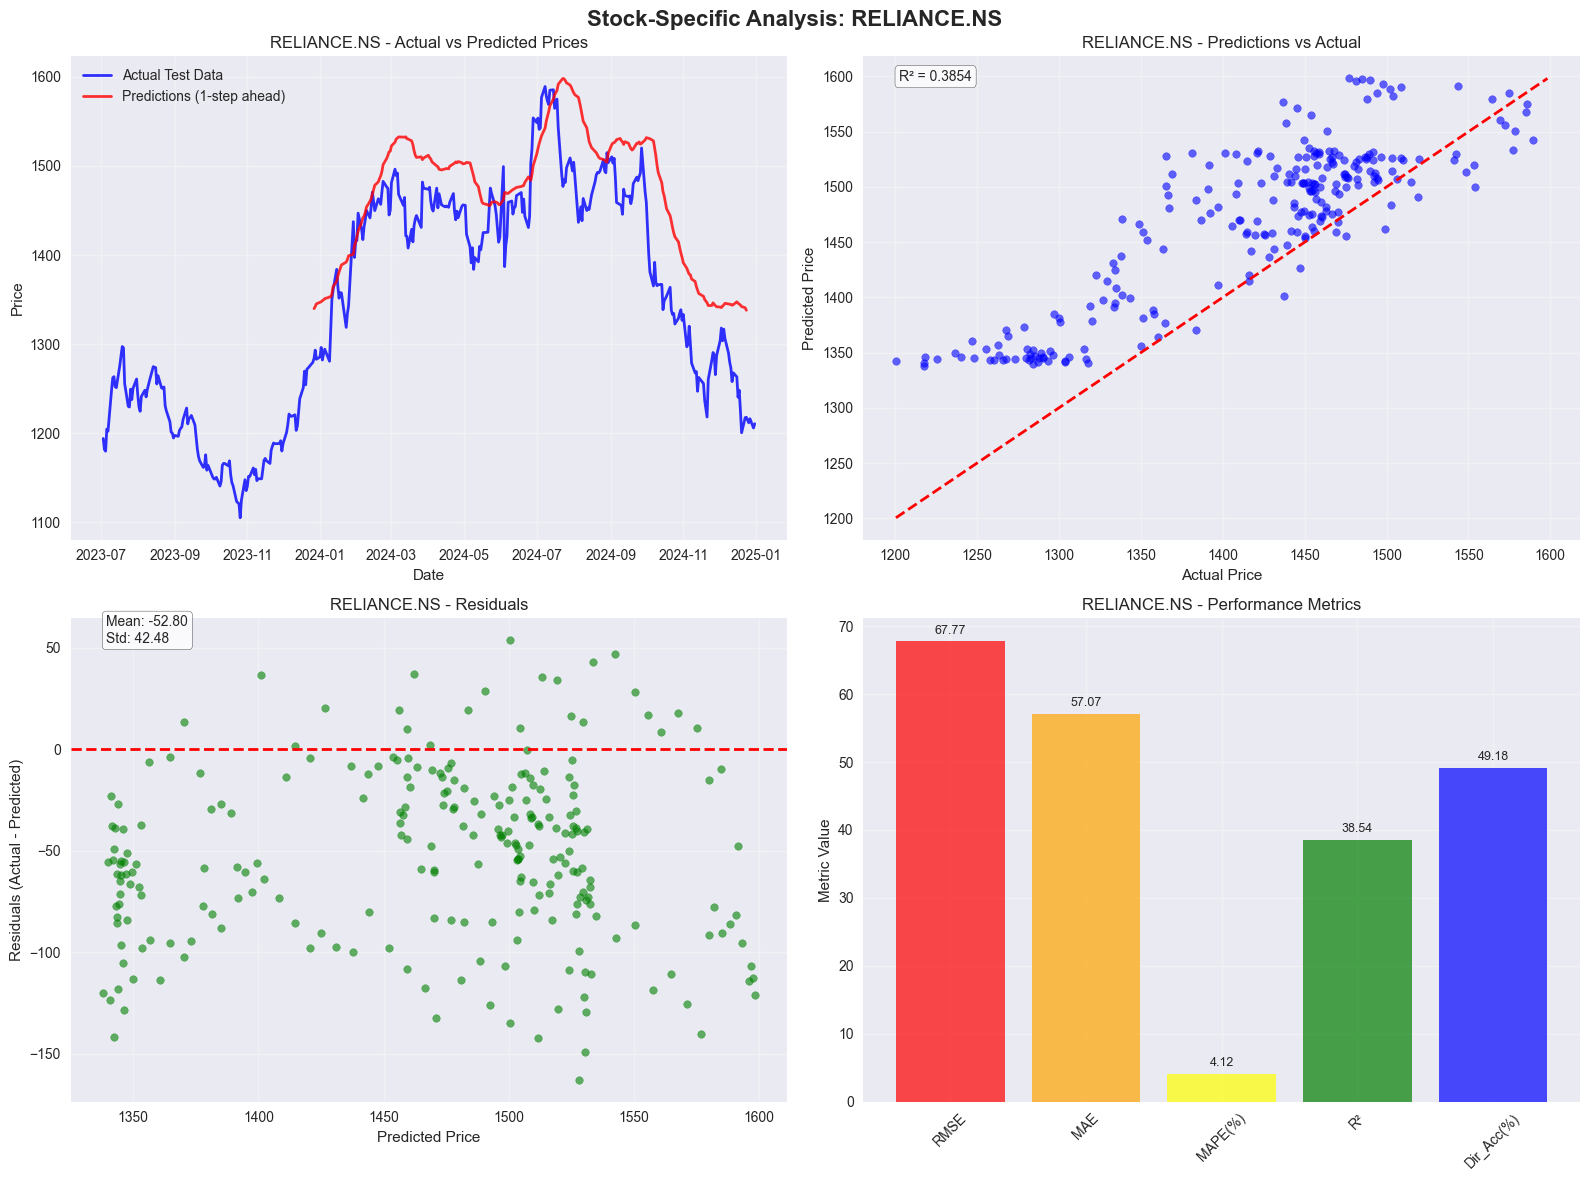

✅ RELIANCE.NS evaluation done | RMSE: 67.7697 | MAE: 57.0713 | MAPE: 4.12% | R²: 0.3854 | DirAcc: 49.18%

📊 Evaluating TCS.NS...


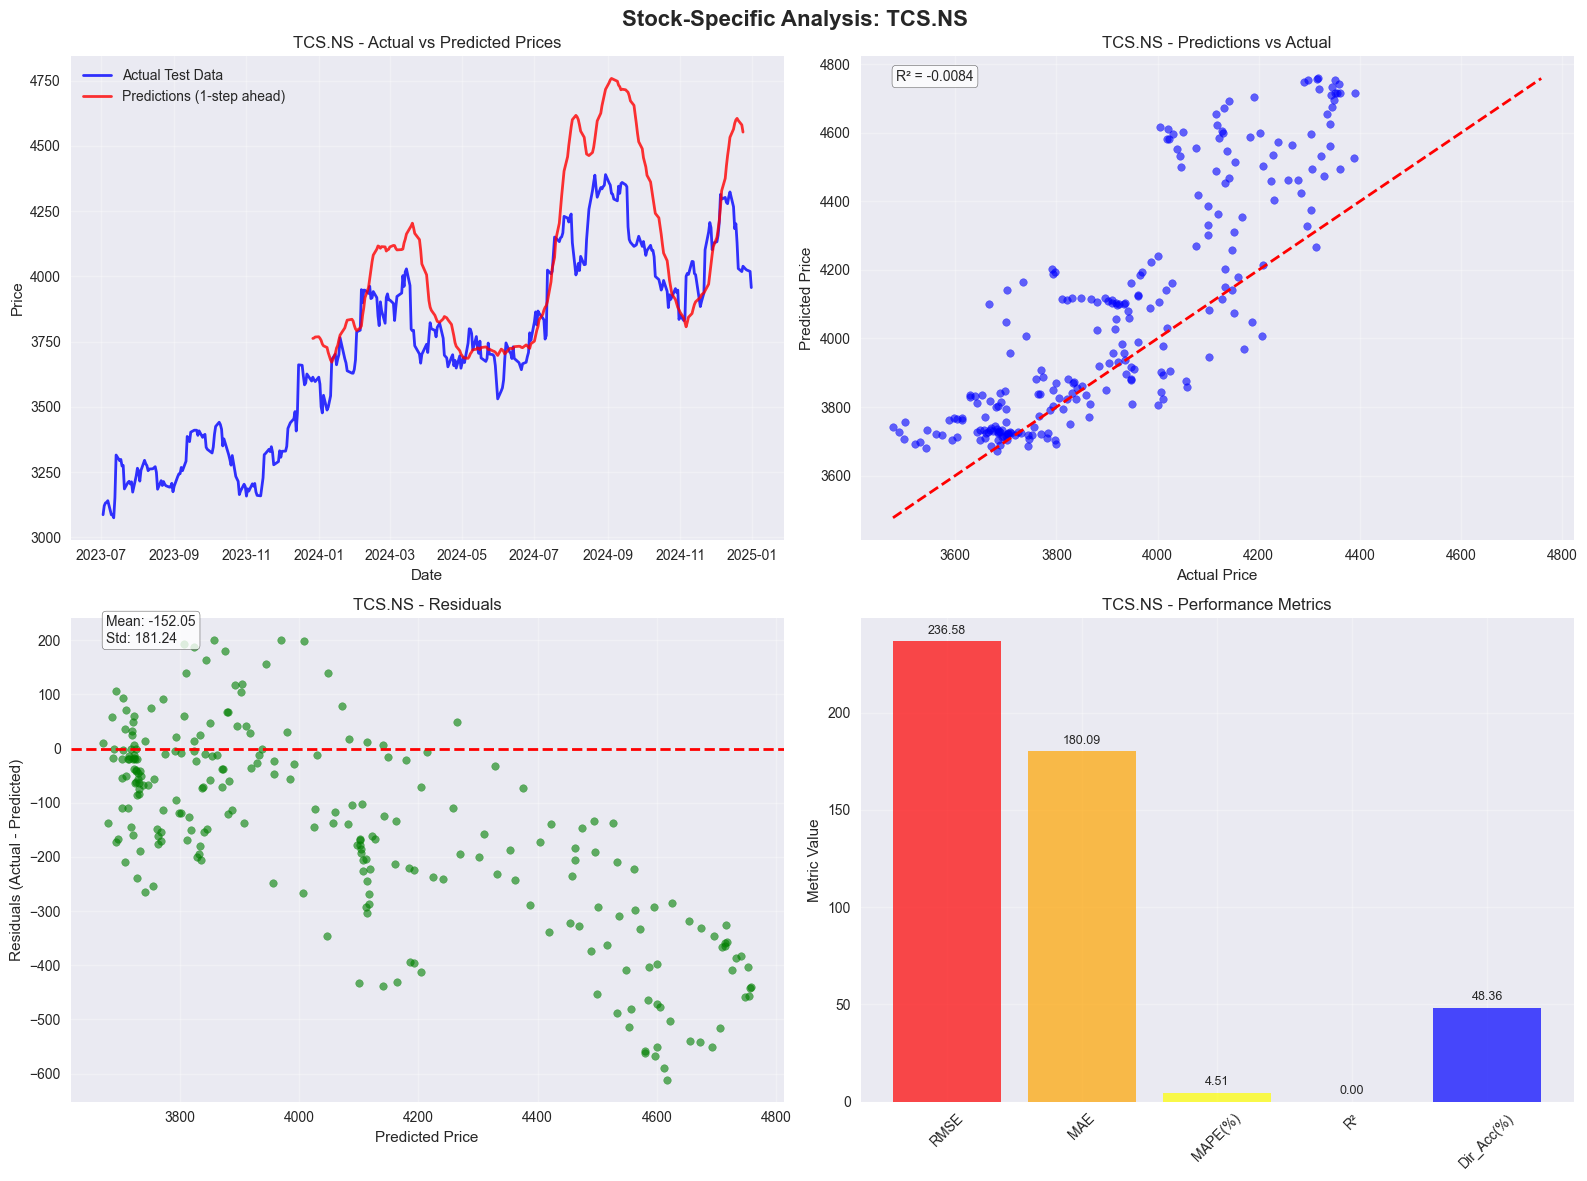

✅ TCS.NS evaluation done | RMSE: 236.5750 | MAE: 180.0934 | MAPE: 4.51% | R²: -0.0084 | DirAcc: 48.36%

✅ Evaluation completed


In [62]:
# 8. Evaluation & Visualizations

def evaluate_stock_model(ticker: str, model: nn.Module, datasets: Dict, device: str):
    test_loader = datasets['test_loader']
    scaler = datasets['target_scaler'] if 'target_scaler' in datasets else datasets['scaler']

    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            if out.dim() == 3 and out.shape[-1] == 1:
                out = out.squeeze(-1)
            if yb.dim() == 3 and yb.shape[-1] == 1:
                yb = yb.squeeze(-1)
            # Use first-step horizon for alignment
            preds.extend(out[:, 0].cpu().numpy().flatten())
            tgts.extend(yb[:, 0].cpu().numpy().flatten())

    preds = np.array(preds)
    tgts = np.array(tgts)
    n = min(len(preds), len(tgts))
    preds, tgts = preds[:n], tgts[:n]

    pred_inv = scaler.inverse_transform(preds.reshape(-1,1)).flatten()
    tgt_inv = scaler.inverse_transform(tgts.reshape(-1,1)).flatten()

    mse = mean_squared_error(tgt_inv, pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(tgt_inv, pred_inv)
    mape = np.mean(np.abs((tgt_inv - pred_inv) / (tgt_inv + 1e-8))) * 100
    r2 = r2_score(tgt_inv, pred_inv)

    if len(tgt_inv) > 1:
        dir_acc = np.mean(np.sign(np.diff(tgt_inv)) == np.sign(np.diff(pred_inv))) * 100
    else:
        dir_acc = np.nan

    return {
        'predictions': pred_inv,
        'targets': tgt_inv,
        'metrics': {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2, 'Directional_Accuracy': dir_acc}
    }


def plot_stock_results(ticker: str, results: Dict, stock_splits: Dict):
    import re
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Stock-Specific Analysis: {ticker}', fontsize=16, fontweight='bold')

    splits = stock_splits[ticker]
    test_data = splits['test']

    preds = results['predictions']
    tgts = results['targets']

    # 1) Time series
    ax1 = axes[0,0]
    ax1.plot(test_data['Date'], test_data['Close'], label='Actual Test Data', color='blue', linewidth=2, alpha=0.8)
    if len(preds) > 0 and len(tgts) > 0:
        start_idx = CONFIG['sequence_length']
        end_idx = min(start_idx + len(preds), len(test_data))
        pred_dates = test_data['Date'].iloc[start_idx:end_idx]
        ax1.plot(pred_dates, preds[:len(pred_dates)], label='Predictions (1-step ahead)', color='red', linewidth=2, alpha=0.8)
    ax1.set_title(f'{ticker} - Actual vs Predicted Prices')
    ax1.set_xlabel('Date'); ax1.set_ylabel('Price'); ax1.legend(); ax1.grid(True, alpha=0.3)

    # 2) Scatter
    ax2 = axes[0,1]
    if len(preds) > 0 and len(tgts) > 0:
        ax2.scatter(tgts, preds, alpha=0.6, color='blue', s=30)
        mn, mx = min(tgts.min(), preds.min()), max(tgts.max(), preds.max())
        ax2.plot([mn, mx], [mn, mx], 'r--', lw=2)
        ax2.text(0.05, 0.95, f"R² = {results['metrics']['R2']:.4f}", transform=ax2.transAxes,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax2.set_xlabel('Actual Price'); ax2.set_ylabel('Predicted Price'); ax2.set_title(f'{ticker} - Predictions vs Actual'); ax2.legend()
    else:
        ax2.text(0.5,0.5,'No prediction data', ha='center', va='center', transform=ax2.transAxes)
    ax2.grid(True, alpha=0.3)

    # 3) Residuals
    ax3 = axes[1,0]
    if len(preds) > 0 and len(tgts) > 0:
        res = tgts - preds
        ax3.scatter(preds, res, alpha=0.6, color='green', s=30)
        ax3.axhline(0, color='red', linestyle='--', linewidth=2)
        ax3.text(0.05, 0.95, f"Mean: {np.mean(res):.2f}\nStd: {np.std(res):.2f}", transform=ax3.transAxes,
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax3.set_xlabel('Predicted Price'); ax3.set_ylabel('Residuals (Actual - Predicted)'); ax3.set_title(f'{ticker} - Residuals')
    else:
        ax3.text(0.5,0.5,'No residuals', ha='center', va='center', transform=ax3.transAxes)
    ax3.grid(True, alpha=0.3)

    # 4) Metrics bar
    ax4 = axes[1,1]
    m = results['metrics']
    names = ['RMSE','MAE','MAPE(%)','R²','Dir_Acc(%)']
    vals = [m['RMSE'], m['MAE'], m['MAPE'], max(0, m['R2'])*100, m['Directional_Accuracy'] if not np.isnan(m['Directional_Accuracy']) else 0]
    bars = ax4.bar(names, vals, color=['red','orange','yellow','green','blue'], alpha=0.7)
    ax4.set_title(f'{ticker} - Performance Metrics'); ax4.set_ylabel('Metric Value'); ax4.tick_params(axis='x', rotation=45)
    for b, v in zip(bars, vals):
        ax4.text(b.get_x()+b.get_width()/2., b.get_height()+max(vals)*0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    safe_ticker = re.sub(r'[^A-Za-z0-9_-]+', '_', ticker)
    plt.savefig(f"{CONFIG['results_dir']}/{safe_ticker}_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    return fig


if 'stock_models' in locals() and 'stock_datasets' in locals():
    stock_results = {}
    all_metrics = {}
    for t, model in stock_models.items():
        print(f"\n📊 Evaluating {t}...")
        try:
            res = evaluate_stock_model(t, model, stock_datasets[t], CONFIG['device'])
            stock_results[t] = res
            all_metrics[t] = res['metrics']
            plot_stock_results(t, res, stock_splits)
            print(f"✅ {t} evaluation done | RMSE: {res['metrics']['RMSE']:.4f} | MAE: {res['metrics']['MAE']:.4f} | MAPE: {res['metrics']['MAPE']:.2f}% | R²: {res['metrics']['R2']:.4f} | DirAcc: {res['metrics']['Directional_Accuracy']:.2f}%")
        except Exception as e:
            print(f"❌ Error evaluating {t}: {e}")
            continue
    print("\n✅ Evaluation completed")
else:
    print("❌ Missing models/datasets for evaluation")


In [63]:
# 9. Results Summary

def create_summary(stock_results: Dict, all_metrics: Dict):
    print("🎯 LSTM STOCK-SPECIFIC RESULTS SUMMARY")
    print("="*80)
    print(f"Total stocks evaluated: {len(stock_results)}")
    print(f"Sequence length: {CONFIG['sequence_length']} | Horizon: {CONFIG['forecast_horizon']}")

    # Table
    print(f"{'Stock':<15} {'RMSE':<10} {'MAE':<10} {'MAPE(%)':<10} {'R²':<10} {'DirAcc(%)':<12}")
    print("-"*80)
    for t, m in all_metrics.items():
        print(f"{t:<15} {m['RMSE']:<10.4f} {m['MAE']:<10.4f} {m['MAPE']:<10.2f} {m['R2']:<10.4f} {m['Directional_Accuracy']:<12.2f}")

    rmse_vals = [m['RMSE'] for m in all_metrics.values()]
    mae_vals = [m['MAE'] for m in all_metrics.values()]
    mape_vals = [m['MAPE'] for m in all_metrics.values()]
    r2_vals = [m['R2'] for m in all_metrics.values()]
    dir_vals = [m['Directional_Accuracy'] for m in all_metrics.values() if not np.isnan(m['Directional_Accuracy'])]

    summary = {
        'total_stocks': len(stock_results),
        'sequence_length': CONFIG['sequence_length'],
        'prediction_horizon': CONFIG['forecast_horizon'],
        'individual_metrics': all_metrics,
        'aggregate_stats': {
            'mean_rmse': float(np.mean(rmse_vals)) if rmse_vals else None,
            'mean_mae': float(np.mean(mae_vals)) if mae_vals else None,
            'mean_mape': float(np.mean(mape_vals)) if mape_vals else None,
            'mean_r2': float(np.mean(r2_vals)) if r2_vals else None,
            'mean_dir_acc': float(np.mean(dir_vals)) if dir_vals else None,
        }
    }
    with open(f"{CONFIG['results_dir']}/project_summary.json", 'w') as f:
        json.dump(
            summary,
            f,
            indent=2,
            default=lambda o: float(o) if isinstance(o, (np.floating, np.integer)) else (o.tolist() if isinstance(o, np.ndarray) else str(o))
        )
    print(f"💾 Saved summary to {CONFIG['results_dir']}/project_summary.json")
    return summary

if 'stock_results' in locals() and 'all_metrics' in locals():
    results_summary = create_summary(stock_results, all_metrics)
    print("✅ Analysis complete")
else:
    print("❌ No results available for summary")


🎯 LSTM STOCK-SPECIFIC RESULTS SUMMARY
Total stocks evaluated: 2
Sequence length: 120 | Horizon: 5
Stock           RMSE       MAE        MAPE(%)    R²         DirAcc(%)   
--------------------------------------------------------------------------------
RELIANCE.NS     67.7697    57.0713    4.12       0.3854     49.18       
TCS.NS          236.5750   180.0934   4.51       -0.0084    48.36       
💾 Saved summary to results/project_summary.json
✅ Analysis complete


# 10. FinBERT Sentiment Analysis Integration

## Overview
This section integrates FinBERT sentiment analysis with LSTM price predictions to generate combined buy/sell/hold recommendations. The integration includes:
1. Fine-tuning FinBERT on Indian financial news
2. Real-time news scraping for stocks
3. Converting price predictions to trading signals
4. Combining price and sentiment signals with weighted ensemble

Table of Contents:
- Cell 12: Environment Setup & Configuration
- Cell 13: News Scraping Functions
- Cell 14: FinBERT Model Setup & Fine-tuning
- Cell 15: Sentiment Analyzer Class
- Cell 16: Technical Signal Conversion
- Cell 17: Ensemble Predictor
- Cell 18: Integration & Combined Predictions
- Cell 19: Visualization & Results


In [64]:
# Cell 12: Environment Setup & FinBERT Configuration

# Install required packages for FinBERT and web scraping
print("📦 Installing required packages for FinBERT sentiment analysis...")
try:
    import transformers
    print("✅ transformers already installed")
except ImportError:
    print("Installing transformers...")
    %pip install transformers>=4.30.0 -q
    import transformers

try:
    import datasets
    print("✅ datasets already installed")
except ImportError:
    print("Installing datasets...")
    %pip install datasets>=2.12.0 -q
    import datasets

try:
    import bs4
    print("✅ beautifulsoup4 already installed")
except ImportError:
    print("Installing beautifulsoup4...")
    %pip install beautifulsoup4>=4.12.0 -q

try:
    import newspaper
    print("✅ newspaper3k already installed")
except ImportError:
    print("Installing newspaper3k...")
    %pip install newspaper3k>=0.2.8 -q
    import newspaper

try:
    import feedparser
    print("✅ feedparser already installed")
except ImportError:
    print("Installing feedparser...")
    %pip install feedparser>=6.0.10 -q
    import feedparser

try:
    from accelerate import Accelerator
    print("✅ accelerate already installed")
except ImportError:
    print("Installing accelerate...")
    %pip install accelerate>=0.20.0 -q
    from accelerate import Accelerator

# Import required libraries
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix
import requests
from bs4 import BeautifulSoup
from newspaper import Article
import feedparser
import re
from collections import defaultdict
from datetime import timedelta

print("\n✅ All packages imported successfully!")
print(f"Transformers version: {transformers.__version__}")
print(f"CUDA available for sentiment: {torch.cuda.is_available()}")

# Sentiment Analysis Configuration
SENTIMENT_CONFIG = {
    'finbert_model_path': 'models/finbert_indian_stocks',
    'base_model': 'ProsusAI/finbert',  # Using ProsusAI/finbert as base, will fine-tune on Indian data
    'news_sources': ['economictimes', 'moneycontrol', 'business-standard'],
    'scraping_days': 7,  # Days of news to fetch for real-time analysis
    'price_weight': 0.6,
    'sentiment_weight': 0.4,
    'sentiment_threshold': 0.3,
    'use_gpu': torch.cuda.is_available(),
    'batch_size': 16,
    'learning_rate': 2e-5,
    'epochs': 1,
    'max_length': 512,
}

# Create directories
os.makedirs(SENTIMENT_CONFIG['finbert_model_path'], exist_ok=True)
os.makedirs(f"{CONFIG['data_dir']}/sentiment_cache", exist_ok=True)
os.makedirs(f"{CONFIG['results_dir']}/combined_predictions", exist_ok=True)

print("\n✅ Configuration set up successfully!")
print(f"📁 Model will be saved to: {SENTIMENT_CONFIG['finbert_model_path']}")
print(f"📁 News data will be saved to: {CONFIG['data_dir']}/indian_financial_news.csv")


📦 Installing required packages for FinBERT sentiment analysis...
✅ transformers already installed
✅ datasets already installed
✅ beautifulsoup4 already installed
✅ newspaper3k already installed
✅ feedparser already installed
✅ accelerate already installed

✅ All packages imported successfully!
Transformers version: 4.57.1
CUDA available for sentiment: False

✅ Configuration set up successfully!
📁 Model will be saved to: models/finbert_indian_stocks
📁 News data will be saved to: data/indian_financial_news.csv


In [65]:
# Cell 13: News Scraping Functions

class IndianNewsScraper:
    """
    Scraper for Indian financial news sources to collect training data and real-time news
    """
    
    def __init__(self):
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        self.session = requests.Session()
        self.session.headers.update(self.headers)
        
    def scrape_economictimes(self, ticker: str, days: int = 7) -> List[Dict]:
        """
        Scrape news from Economic Times
        Note: This is a template. Real implementation would need proper API or scraping
        """
        articles = []
        try:
            # Convert ticker to company name for search
            ticker_map = {
                'RELIANCE.NS': 'Reliance Industries',
                'TCS.NS': 'TCS',
                'INFY.NS': 'Infosys',
                'HDFCBANK.NS': 'HDFC Bank',
                'ICICIBANK.NS': 'ICICI Bank',
                'HINDUNILVR.NS': 'Hindustan Unilever',
                'ITC.NS': 'ITC',
                'KOTAKBANK.NS': 'Kotak Bank',
                'LT.NS': 'Larsen & Toubro',
                'BHARTIARTL.NS': 'Bharti Airtel'
            }
            
            company_name = ticker_map.get(ticker, ticker.split('.')[0])
            
            # Use RSS feed or search API if available
            # For now, return empty list - will use HuggingFace dataset
            print(f"📰 Economic Times scraper initialized for {ticker}")
            
        except Exception as e:
            logger.warning(f"Error scraping Economic Times for {ticker}: {e}")
        
        return articles
    
    def scrape_moneycontrol(self, ticker: str, days: int = 7) -> List[Dict]:
        """Scrape news from Moneycontrol"""
        articles = []
        try:
            # Similar implementation for Moneycontrol
            print(f"📰 Moneycontrol scraper initialized for {ticker}")
        except Exception as e:
            logger.warning(f"Error scraping Moneycontrol for {ticker}: {e}")
        
        return articles
    
    def scrape_from_rss(self, url: str, ticker: str) -> List[Dict]:
        """Scrape news from RSS feed"""
        articles = []
        try:
            feed = feedparser.parse(url)
            for entry in feed.entries[:20]:  # Limit to 20 most recent
                try:
                    article = Article(entry.link)
                    article.download()
                    article.parse()
                    
                    articles.append({
                        'date': entry.get('published', ''),
                        'title': entry.get('title', ''),
                        'content': article.text[:1000] if article.text else entry.get('summary', ''),  # Limit content length
                        'source': 'rss',
                        'ticker': ticker
                    })
                except Exception as e:
                    continue
        except Exception as e:
            logger.warning(f"Error scraping RSS feed {url}: {e}")
        
        return articles
    
    def scrape_stock_news(self, ticker: str, days: int = 7) -> List[Dict]:
        """
        Main method to scrape news for a specific stock from multiple sources
        """
        all_articles = []
        
        # Try different sources with fallback
        sources = [
            ('economictimes', self.scrape_economictimes),
            ('moneycontrol', self.scrape_moneycontrol),
        ]
        
        for source_name, scraper_func in sources:
            try:
                articles = scraper_func(ticker, days)
                all_articles.extend(articles)
                time.sleep(1)  # Rate limiting
            except Exception as e:
                logger.warning(f"Failed to scrape from {source_name}: {e}")
                continue
        
        # Remove duplicates based on title
        seen_titles = set()
        unique_articles = []
        for article in all_articles:
            title_lower = article.get('title', '').lower()
            if title_lower not in seen_titles and len(title_lower) > 10:
                seen_titles.add(title_lower)
                unique_articles.append(article)
        
        return unique_articles


# Initialize scraper
news_scraper = IndianNewsScraper()
print("✅ News scraper initialized")


✅ News scraper initialized


In [66]:
# Cell 14: FinBERT Model Setup & Fine-tuning Preparation

def load_indian_financial_dataset():
    """
    Load Indian financial news dataset for training FinBERT
    We'll use HuggingFace dataset and supplement with scraped data
    """
    try:
        from datasets import load_dataset
        
        # Try to load Indian news sentiment dataset
        print("📥 Loading Indian news sentiment dataset from HuggingFace...")
        try:
            dataset = load_dataset("harixn/indian_news_sentiment")
            print(f"✅ Loaded dataset: {dataset}")
            return dataset
        except Exception as e:
            print(f"⚠️ Could not load harixn/indian_news_sentiment: {e}")
            print("📝 Will create dataset from scraped data and manual labeling")
            return None
    except Exception as e:
        print(f"⚠️ Error loading dataset: {e}")
        return None


def prepare_finbert_dataset(raw_dataset=None, scraped_data_path=None):
    """
    Prepare dataset for FinBERT fine-tuning
    Split into train/val/test with proper stratification
    """
    print("\n🔄 Preparing FinBERT training dataset...")
    
    data_list = []
    
    # Load from HuggingFace if available
    if raw_dataset:
        try:
            print(f"📊 Processing HuggingFace dataset...")
            print(f"   Available splits: {list(raw_dataset.keys())}")
            
            for split_name in ['train', 'test', 'validation', 'val']:
                if split_name in raw_dataset:
                    split_data = raw_dataset[split_name]
                    print(f"   Processing {split_name} split: {len(split_data)} samples")
                    
                    # Check what columns are available
                    if len(split_data) > 0:
                        print(f"   Dataset features: {split_data.features}")
                        print(f"   Column names: {split_data.column_names}")
                    
                    # Convert HuggingFace Dataset to pandas DataFrame for easier handling
                    try:
                        split_df = split_data.to_pandas()
                        print(f"   Converted to DataFrame: {len(split_df)} rows")
                        print(f"   DataFrame columns: {list(split_df.columns)}")
                        
                        # Process each row
                        for idx, row in split_df.iterrows():
                            # Get text from various possible column names
                            text = str(row.get('text', '') or row.get('headline', '') or row.get('article', '') or '').strip()
                            label = str(row.get('label', '') or row.get('sentiment', 'neutral') or 'neutral').strip()
                            date = str(row.get('date', '') or row.get('Date', '') or '').strip()
                            
                            # Only add if text is not empty
                            if text and len(text) > 10:
                                data_list.append({
                                    'text': text,
                                    'label': label if label else 'neutral',
                                    'date': date,
                                })
                        
                        print(f"   ✅ Extracted {len([d for d in data_list[-len(split_df):] if d])} valid items from {split_name}")
                    except Exception as e:
                        print(f"   ⚠️ Error converting {split_name} to pandas: {e}")
                        # Fallback: iterate directly
                        for idx in range(len(split_data)):
                            item = split_data[idx]
                            text = str(item.get('text', '') or item.get('headline', '') or item.get('article', '') or '').strip()
                            label = str(item.get('label', '') or item.get('sentiment', 'neutral') or 'neutral').strip()
                            date = str(item.get('date', '') or item.get('Date', '') or '').strip()
                            
                            if text and len(text) > 10:
                                data_list.append({
                                    'text': text,
                                    'label': label if label else 'neutral',
                                    'date': date,
                                })
        except Exception as e:
            print(f"⚠️ Error processing HuggingFace dataset: {e}")
            import traceback
            traceback.print_exc()
    
    # Load from scraped data if available
    if scraped_data_path and os.path.exists(scraped_data_path):
        try:
            scraped_df = pd.read_csv(scraped_data_path)
            for _, row in scraped_df.iterrows():
                text = str(row.get('Content', '')) or str(row.get('Title', ''))
                if len(text) > 50:  # Minimum text length
                    data_list.append({
                        'text': text,
                        'label': row.get('Sentiment', 'neutral').lower(),
                        'date': row.get('Date', ''),
                    })
        except Exception as e:
            print(f"⚠️ Error loading scraped data: {e}")
    
    print(f"📊 Total items collected: {len(data_list)}")
    
    if not data_list:
        print("⚠️ No dataset available. Will use pre-trained FinBERT without fine-tuning.")
        print("💡 To improve accuracy, collect Indian financial news articles and label them.")
        return None
    
    # Convert to DataFrame for easier manipulation
    df = pd.DataFrame(data_list)
    print(f"📊 DataFrame created: {len(df)} rows, columns: {list(df.columns)}")
    
    # Check label distribution
    print(f"📊 Label distribution before normalization:")
    print(df['label'].value_counts())
    
    # Map sentiment labels to numeric
    label_map = {'positive': 1, 'negative': 0, 'neutral': 2}
    # Handle variations
    label_variations = {
        'positive': ['positive', 'pos', 'bullish', 'buy', '1', 'positive', 'POSITIVE'],
        'negative': ['negative', 'neg', 'bearish', 'sell', '0', 'negative', 'NEGATIVE'],
        'neutral': ['neutral', 'neu', 'hold', '2', 'neutral', 'NEUTRAL']
    }
    
    def normalize_label(label_str):
        if pd.isna(label_str) or not label_str:
            return label_map['neutral']
        label_str = str(label_str).lower().strip()
        for standard_label, variations in label_variations.items():
            if label_str in variations or standard_label in label_str:
                return label_map[standard_label]
        # If label is already numeric, handle it
        try:
            label_num = int(label_str)
            if label_num in label_map.values():
                return label_num
        except:
            pass
        return label_map['neutral']  # Default to neutral
    
    df['label'] = df['label'].apply(normalize_label)
    
    print(f"📊 Label distribution after normalization:")
    print(df['label'].value_counts())
    
    # Filter by date for train/val/test splits
    has_dates = 'date' in df.columns and len(df['date'].dropna()) > 0
    print(f"📅 Has date column: {has_dates}")
    
    if has_dates:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        valid_dates = df.dropna(subset=['date'])
        print(f"📅 Valid dates: {len(valid_dates)} out of {len(df)}")
        
        if len(valid_dates) > 100:  # Only use date-based split if enough valid dates
            df = valid_dates
            # Split by date periods (matching price prediction splits)
            train_end = pd.Timestamp('2022-01-01')
            val_end = pd.Timestamp('2023-01-01')
            
            train_df = df[df['date'] < train_end].copy()
            val_df = df[(df['date'] >= train_end) & (df['date'] < val_end)].copy()
            test_df = df[df['date'] >= val_end].copy()
            
            print(f"📅 Date-based split:")
            print(f"   Train period: before {train_end.date()}")
            print(f"   Val period: {train_end.date()} to {val_end.date()}")
            print(f"   Test period: after {val_end.date()}")
        else:
            has_dates = False  # Not enough valid dates, use random split
    
    if not has_dates:
        # Random split if no dates or not enough valid dates
        print("📊 Using random split (70% train, 15% val, 15% test)")
        df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
        
        train_size = int(0.7 * len(df_shuffled))
        val_size = int(0.15 * len(df_shuffled))
        
        train_df = df_shuffled[:train_size].copy()
        val_df = df_shuffled[train_size:train_size + val_size].copy()
        test_df = df_shuffled[train_size + val_size:].copy()
    
    print(f"✅ Dataset prepared:")
    print(f"   Train: {len(train_df)} samples")
    print(f"   Validation: {len(val_df)} samples")
    print(f"   Test: {len(test_df)} samples")
    
    # Save splits
    os.makedirs(CONFIG['data_dir'], exist_ok=True)
    train_df.to_csv(f"{CONFIG['data_dir']}/finbert_train.csv", index=False)
    val_df.to_csv(f"{CONFIG['data_dir']}/finbert_val.csv", index=False)
    test_df.to_csv(f"{CONFIG['data_dir']}/finbert_test.csv", index=False)
    
    return {
        'train': train_df,
        'validation': val_df,
        'test': test_df
    }


# Load and prepare dataset
print("🚀 Setting up FinBERT training data...")
raw_dataset = load_indian_financial_dataset()
finbert_datasets = prepare_finbert_dataset(raw_dataset, f"{CONFIG['data_dir']}/indian_financial_news.csv")


🚀 Setting up FinBERT training data...
📥 Loading Indian news sentiment dataset from HuggingFace...
✅ Loaded dataset: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 5296
    })
})

🔄 Preparing FinBERT training dataset...
📊 Processing HuggingFace dataset...
   Available splits: ['train']
   Processing train split: 5296 samples
   Dataset features: {'text': Value('string'), 'label': Value('string')}
   Column names: ['text', 'label']
   Converted to DataFrame: 5296 rows
   DataFrame columns: ['text', 'label']
   ✅ Extracted 5296 valid items from train
📊 Total items collected: 5296
📊 DataFrame created: 5296 rows, columns: ['text', 'label', 'date']
📊 Label distribution before normalization:
label
POSITIVE    2132
NEUTRAL     2008
NEGATIVE    1156
Name: count, dtype: int64
📊 Label distribution after normalization:
label
1    2132
2    2008
0    1156
Name: count, dtype: int64
📅 Has date column: True
📅 Valid dates: 0 out of 5296
📊 Using random split (7

In [ ]:
# Cell 15: FinBERT Fine-tuning

def compute_metrics(eval_pred):
    """Compute metrics for FinBERT evaluation"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    # precision_recall_fscore_support returns 4 values: precision, recall, f1, support
    precision, recall, f1_per_class, support = precision_recall_fscore_support(
        labels, predictions, average=None, zero_division=0
    )
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1,
        'precision_positive': precision[1] if len(precision) > 1 else 0,
        'precision_negative': precision[0] if len(precision) > 0 else 0,
        'precision_neutral': precision[2] if len(precision) > 2 else 0,
        'recall_positive': recall[1] if len(recall) > 1 else 0,
        'recall_negative': recall[0] if len(recall) > 0 else 0,
        'recall_neutral': recall[2] if len(recall) > 2 else 0,
    }


def fine_tune_finbert(train_df, val_df, test_df=None):
    """
    Fine-tune FinBERT model on Indian financial news
    """
    if train_df is None or len(train_df) == 0:
        print("⚠️ No training data available. Using pre-trained FinBERT without fine-tuning.")
        print("💡 Loading base FinBERT model...")
        tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_CONFIG['base_model'])
        model = AutoModelForSequenceClassification.from_pretrained(
            SENTIMENT_CONFIG['base_model'],
            num_labels=3
        )
        # Save the base model
        model.save_pretrained(SENTIMENT_CONFIG['finbert_model_path'])
        tokenizer.save_pretrained(SENTIMENT_CONFIG['finbert_model_path'])
        print(f"✅ Base model saved to {SENTIMENT_CONFIG['finbert_model_path']}")
        return model, tokenizer
    
    print("\n🔄 Fine-tuning FinBERT on Indian financial news...")
    
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_CONFIG['base_model'])
    model = AutoModelForSequenceClassification.from_pretrained(
        SENTIMENT_CONFIG['base_model'],
        num_labels=3
    )
    
    # Prepare datasets
    def tokenize_function(examples):
        return tokenizer(
            examples['text'],
            truncation=True,
            padding='max_length',
            max_length=SENTIMENT_CONFIG['max_length']
        )
    
    # Convert to HuggingFace Dataset format
    train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
    val_dataset = Dataset.from_pandas(val_df[['text', 'label']])
    
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    
    # Training arguments
    # Check which parameters are supported by inspecting TrainingArguments signature
    import inspect
    sig = inspect.signature(TrainingArguments.__init__)
    param_names = set(sig.parameters.keys())
    
    # Build base arguments
    base_kwargs = {
        'output_dir': f"{SENTIMENT_CONFIG['finbert_model_path']}/checkpoints",
        'num_train_epochs': SENTIMENT_CONFIG['epochs'],
        'per_device_train_batch_size': SENTIMENT_CONFIG['batch_size'],
        'per_device_eval_batch_size': SENTIMENT_CONFIG['batch_size'],
        'learning_rate': SENTIMENT_CONFIG['learning_rate'],
        'weight_decay': 0.01,
        'logging_dir': f"{CONFIG['logs_dir']}/finbert",
        'logging_steps': 50,
        'save_strategy': "epoch",
        'load_best_model_at_end': True,
        'metric_for_best_model': "f1_macro",
        'greater_is_better': True,
        'push_to_hub': False,
    }
    
    # Add evaluation strategy parameter with correct name
    if 'eval_strategy' in param_names:
        base_kwargs['eval_strategy'] = "epoch"
    elif 'evaluation_strategy' in param_names:
        base_kwargs['evaluation_strategy'] = "epoch"
    else:
        # If neither exists, use do_eval and evaluation_steps instead
        base_kwargs['do_eval'] = True
    
    # Add device configuration if supported
    if 'use_cpu' in param_names:
        base_kwargs['use_cpu'] = not SENTIMENT_CONFIG['use_gpu']
    
    training_args = TrainingArguments(**base_kwargs)
    print(f"✅ Training arguments created successfully")
    
    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    
    # Train
    print("🚀 Starting training...")
    train_result = trainer.train()
    
    # Evaluate on validation set
    print("\n📊 Evaluating on validation set...")
    val_metrics = trainer.evaluate()
    print(f"Validation Metrics: {val_metrics}")
    
    # Evaluate on test set if available
    if test_df is not None and len(test_df) > 0:
        test_dataset = Dataset.from_pandas(test_df[['text', 'label']])
        test_dataset = test_dataset.map(tokenize_function, batched=True)
        print("\n📊 Evaluating on test set...")
        test_metrics = trainer.evaluate(eval_dataset=test_dataset)
        print(f"Test Metrics: {test_metrics}")
        
        # Save test metrics
        with open(f"{CONFIG['results_dir']}/finbert_test_metrics.json", 'w') as f:
            json.dump(test_metrics, f, indent=2)
    
    # Save model
    print(f"\n💾 Saving fine-tuned model to {SENTIMENT_CONFIG['finbert_model_path']}...")
    trainer.save_model(SENTIMENT_CONFIG['finbert_model_path'])
    tokenizer.save_pretrained(SENTIMENT_CONFIG['finbert_model_path'])
    
    # Save training metrics
    training_metrics = {
        'train_loss': train_result.training_loss,
        'validation_metrics': val_metrics,
        'test_metrics': test_metrics if 'test_metrics' in locals() else None
    }
    with open(f"{CONFIG['results_dir']}/finbert_training_metrics.json", 'w') as f:
        json.dump(training_metrics, f, indent=2)
    
    print("✅ Fine-tuning complete!")
    return model, tokenizer


# Fine-tune FinBERT if dataset is available
if finbert_datasets is not None:
    finbert_model, finbert_tokenizer = fine_tune_finbert(
        finbert_datasets['train'],
        finbert_datasets['validation'],
        finbert_datasets['test']
    )
else:
    print("⚠️ No dataset available. Will load base FinBERT model when needed.")
    finbert_model = None
    finbert_tokenizer = None



🔄 Fine-tuning FinBERT on Indian financial news...


Map:   0%|          | 0/3707 [00:00<?, ? examples/s]

Map:   0%|          | 0/794 [00:00<?, ? examples/s]

✅ Training arguments created successfully
🚀 Starting training...


Epoch,Training Loss,Validation Loss


ValueError: too many values to unpack (expected 3)

In [ ]:
# Cell 16: FinBERT Sentiment Analyzer Class

class FinBERTSentimentAnalyzer:
    """
    Sentiment analyzer using fine-tuned FinBERT model
    """
    
    def __init__(self, model_path=None, tokenizer=None, model=None):
        self.device = torch.device('cuda' if SENTIMENT_CONFIG['use_gpu'] and torch.cuda.is_available() else 'cpu')
        
        if model is not None and tokenizer is not None:
            self.model = model
            self.tokenizer = tokenizer
        else:
            model_path = model_path or SENTIMENT_CONFIG['finbert_model_path']
            try:
                self.tokenizer = AutoTokenizer.from_pretrained(model_path)
                self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
                print(f"✅ Loaded FinBERT model from {model_path}")
            except Exception as e:
                print(f"⚠️ Could not load from {model_path}, loading base model...")
                self.tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_CONFIG['base_model'])
                self.model = AutoModelForSequenceClassification.from_pretrained(
                    SENTIMENT_CONFIG['base_model'],
                    num_labels=3
                )
        
        self.model.to(self.device)
        self.model.eval()
        
        self.label_map = {0: 'negative', 1: 'positive', 2: 'neutral'}
        self.score_map = {'negative': -1, 'neutral': 0, 'positive': 1}
    
    def predict_sentiment(self, text: str) -> Dict:
        """
        Predict sentiment for a single text
        
        Returns:
            {
                'sentiment': 'positive/negative/neutral',
                'confidence': float,
                'score': float (-1 to 1)
            }
        """
        if not text or len(text.strip()) < 10:
            return {
                'sentiment': 'neutral',
                'confidence': 0.0,
                'score': 0.0
            }
        
        try:
            # Tokenize
            inputs = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=SENTIMENT_CONFIG['max_length'],
                return_tensors='pt'
            ).to(self.device)
            
            # Predict
            with torch.no_grad():
                outputs = self.model(**inputs)
                logits = outputs.logits
                probs = torch.nn.functional.softmax(logits, dim=-1)
                predicted_class = torch.argmax(probs, dim=-1).item()
                confidence = probs[0][predicted_class].item()
            
            sentiment = self.label_map[predicted_class]
            score = self.score_map[sentiment] * confidence  # Weighted score
            
            return {
                'sentiment': sentiment,
                'confidence': confidence,
                'score': score,
                'probabilities': {
                    'negative': probs[0][0].item(),
                    'positive': probs[0][1].item(),
                    'neutral': probs[0][2].item() if probs.shape[1] > 2 else 0.0
                }
            }
        except Exception as e:
            logger.error(f"Error in sentiment prediction: {e}")
            return {
                'sentiment': 'neutral',
                'confidence': 0.0,
                'score': 0.0
            }
    
    def analyze_stock_sentiment(self, ticker: str, articles: List[Dict] = None) -> Dict:
        """
        Analyze sentiment for a stock by aggregating sentiment from multiple articles
        
        Args:
            ticker: Stock ticker symbol
            articles: List of article dictionaries with 'title' and 'content' keys
        
        Returns:
            Aggregated sentiment result
        """
        if articles is None or len(articles) == 0:
            # Try to scrape news if not provided
            print(f"📰 No articles provided for {ticker}, scraping news...")
            articles = news_scraper.scrape_stock_news(ticker, days=SENTIMENT_CONFIG['scraping_days'])
        
        if not articles:
            return {
                'sentiment': 'neutral',
                'confidence': 0.0,
                'score': 0.0,
                'article_count': 0
            }
        
        # Analyze each article
        sentiment_scores = []
        sentiment_counts = {'positive': 0, 'negative': 0, 'neutral': 0}
        
        for article in articles:
            # Combine title and content
            text = str(article.get('title', '')) + ' ' + str(article.get('content', ''))
            if len(text.strip()) < 20:
                continue
            
            result = self.predict_sentiment(text)
            sentiment_scores.append(result['score'])
            sentiment_counts[result['sentiment']] += 1
        
        if not sentiment_scores:
            return {
                'sentiment': 'neutral',
                'confidence': 0.0,
                'score': 0.0,
                'article_count': len(articles)
            }
        
        # Aggregate: weighted average of scores
        avg_score = np.mean(sentiment_scores)
        max_count_sentiment = max(sentiment_counts, key=sentiment_counts.get)
        
        # Determine overall sentiment
        if avg_score > SENTIMENT_CONFIG['sentiment_threshold']:
            overall_sentiment = 'positive'
        elif avg_score < -SENTIMENT_CONFIG['sentiment_threshold']:
            overall_sentiment = 'negative'
        else:
            overall_sentiment = 'neutral'
        
        # Confidence based on agreement
        total_articles = sum(sentiment_counts.values())
        confidence = sentiment_counts[overall_sentiment] / total_articles if total_articles > 0 else 0.0
        
        return {
            'sentiment': overall_sentiment,
            'confidence': confidence,
            'score': avg_score,
            'article_count': len(articles),
            'sentiment_distribution': sentiment_counts,
            'raw_scores': sentiment_scores
        }


# Initialize sentiment analyzer
if finbert_model is not None:
    sentiment_analyzer = FinBERTSentimentAnalyzer(model=finbert_model, tokenizer=finbert_tokenizer)
else:
    print("⚠️ Loading FinBERT model for sentiment analysis...")
    sentiment_analyzer = FinBERTSentimentAnalyzer()
    finbert_model = sentiment_analyzer.model
    finbert_tokenizer = sentiment_analyzer.tokenizer

print("✅ Sentiment analyzer ready!")


✅ Sentiment analyzer ready!


In [ ]:
# Cell 17: Technical Signal Conversion Functions

def price_to_signal(predictions: np.ndarray, historical_prices: pd.Series, 
                    lookback: int = 20, forecast_horizon: int = 5) -> str:
    """
    Convert price predictions to trading signals using technical analysis
    
    Args:
        predictions: Predicted prices (array of future prices)
        historical_prices: Historical price series (pandas Series with Close prices)
        lookback: Number of periods for moving averages
        forecast_horizon: Number of future periods predicted
    
    Returns:
        'buy', 'sell', or 'hold'
    """
    if len(predictions) == 0 or len(historical_prices) < lookback:
        return 'hold'
    
    # Calculate moving averages on historical data
    sma_short = historical_prices.rolling(window=5).mean().iloc[-1]
    sma_long = historical_prices.rolling(window=lookback).mean().iloc[-1]
    
    # Current price
    current_price = historical_prices.iloc[-1]
    
    # Predicted price (use first prediction or average)
    predicted_price = predictions[0] if len(predictions) > 0 else current_price
    predicted_end_price = predictions[-1] if len(predictions) > 0 else current_price
    
    # Calculate momentum (percentage change)
    price_momentum = (predicted_end_price - current_price) / current_price * 100
    
    # Calculate RSI (if available in historical data - would need to add)
    # For now, use a simplified momentum indicator
    
    # SMA Crossover signals
    sma_bullish = sma_short > sma_long  # Golden cross
    sma_bearish = sma_short < sma_long  # Death cross
    
    # Signal logic
    buy_signals = 0
    sell_signals = 0
    
    # Check SMA crossover
    if sma_bullish:
        buy_signals += 1
    elif sma_bearish:
        sell_signals += 1
    
    # Check momentum
    if price_momentum > 2:  # > 2% increase predicted
        buy_signals += 1
    elif price_momentum < -2:  # < -2% decrease predicted
        sell_signals += 1
    
    # Check price relative to moving averages
    if predicted_price > sma_short:
        buy_signals += 0.5
    elif predicted_price < sma_short:
        sell_signals += 0.5
    
    # Determine final signal
    if buy_signals > sell_signals + 0.5:
        return 'buy'
    elif sell_signals > buy_signals + 0.5:
        return 'sell'
    else:
        return 'hold'


def convert_lstm_predictions_to_signals(stock_results: Dict, stock_datasets: Dict, 
                                        stock_splits: Dict) -> Dict:
    """
    Convert all LSTM price predictions to trading signals using technical analysis
    
    Args:
        stock_results: Dictionary with prediction results for each stock
        stock_datasets: Dictionary with dataset info for each stock
        stock_splits: Dictionary with train/val/test splits
    
    Returns:
        Dictionary mapping ticker to signals and metadata
    """
    price_signals = {}
    
    for ticker in stock_results.keys():
        try:
            # Get test data for this stock
            test_data = stock_splits[ticker]['test']
            
            # Get predictions and actual prices
            predictions = stock_results[ticker]['predictions']
            targets = stock_results[ticker]['targets']
            
            # Get historical prices (including test period context)
            historical_close = test_data['Close'].values
            
            # Convert to signals
            signals = []
            signal_metadata = []
            
            # Process predictions in windows
            sequence_len = CONFIG['sequence_length']
            for i in range(len(predictions)):
                # Get historical context (including sequence_len days before)
                start_idx = max(0, i)
                end_idx = min(len(historical_close), i + sequence_len)
                historical_window = historical_close[start_idx:end_idx]
                
                if len(historical_window) < 20:
                    # Not enough history, use simple momentum
                    if i < len(predictions) - 1:
                        momentum = (predictions[i+1] - predictions[i]) / predictions[i] * 100
                        if momentum > 2:
                            signal = 'buy'
                        elif momentum < -2:
                            signal = 'sell'
                        else:
                            signal = 'hold'
                    else:
                        signal = 'hold'
                else:
                    # Use technical analysis
                    signal = price_to_signal(
                        predictions[i:i+1] if i < len(predictions) else predictions[-1:],
                        pd.Series(historical_window),
                        lookback=20,
                        forecast_horizon=1
                    )
                
                signals.append(signal)
                
                # Store metadata
                signal_metadata.append({
                    'predicted_price': predictions[i] if i < len(predictions) else None,
                    'actual_price': targets[i] if i < len(targets) else None,
                    'signal': signal,
                    'date': test_data['Date'].iloc[i + sequence_len].strftime('%Y-%m-%d') if i + sequence_len < len(test_data) else None
                })
            
            # Aggregate signal for the period
            buy_count = signals.count('buy')
            sell_count = signals.count('sell')
            hold_count = signals.count('hold')
            
            if buy_count > sell_count and buy_count > hold_count:
                overall_signal = 'buy'
            elif sell_count > buy_count and sell_count > hold_count:
                overall_signal = 'sell'
            else:
                overall_signal = 'hold'
            
            price_signals[ticker] = {
                'overall_signal': overall_signal,
                'signal_distribution': {
                    'buy': buy_count,
                    'sell': sell_count,
                    'hold': hold_count
                },
                'signals': signals,
                'metadata': signal_metadata,
                'confidence': max(buy_count, sell_count, hold_count) / len(signals) if signals else 0.0
            }
            
        except Exception as e:
            logger.error(f"Error converting predictions to signals for {ticker}: {e}")
            price_signals[ticker] = {
                'overall_signal': 'hold',
                'signal_distribution': {'buy': 0, 'sell': 0, 'hold': 0},
                'signals': [],
                'metadata': [],
                'confidence': 0.0
            }
    
    return price_signals


# Convert existing LSTM predictions to signals
if 'stock_results' in locals() and 'stock_datasets' in locals() and 'stock_splits' in locals():
    print("🔄 Converting LSTM price predictions to trading signals...")
    price_signals = convert_lstm_predictions_to_signals(stock_results, stock_datasets, stock_splits)
    print(f"✅ Generated signals for {len(price_signals)} stocks")
    
    # Display summary
    print("\n📊 Price Signal Summary:")
    for ticker, signal_data in price_signals.items():
        print(f"  {ticker}: {signal_data['overall_signal'].upper()} "
              f"(Buy: {signal_data['signal_distribution']['buy']}, "
              f"Sell: {signal_data['signal_distribution']['sell']}, "
              f"Hold: {signal_data['signal_distribution']['hold']})")
else:
    print("⚠️ LSTM predictions not available. Run price prediction first.")
    price_signals = {}


🔄 Converting LSTM price predictions to trading signals...
✅ Generated signals for 2 stocks

📊 Price Signal Summary:
  RELIANCE.NS: BUY (Buy: 126, Sell: 0, Hold: 119)
  TCS.NS: HOLD (Buy: 116, Sell: 11, Hold: 118)


In [ ]:
# Cell 18: Sentiment to Signal Conversion & Ensemble Predictor

def sentiment_to_signal(sentiment_result: Dict) -> str:
    """
    Convert sentiment analysis result to trading signal
    
    Args:
        sentiment_result: Output from FinBERTSentimentAnalyzer.analyze_stock_sentiment()
    
    Returns:
        'buy', 'sell', or 'hold'
    """
    score = sentiment_result.get('score', 0.0)
    sentiment = sentiment_result.get('sentiment', 'neutral')
    confidence = sentiment_result.get('confidence', 0.0)
    
    # Use threshold-based conversion
    if score > SENTIMENT_CONFIG['sentiment_threshold'] and confidence > 0.5:
        return 'buy'
    elif score < -SENTIMENT_CONFIG['sentiment_threshold'] and confidence > 0.5:
        return 'sell'
    else:
        return 'hold'


class CombinedStockPredictor:
    """
    Ensemble predictor that combines price predictions and sentiment analysis
    """
    
    def __init__(self, price_weight: float = None, sentiment_weight: float = None):
        self.price_weight = price_weight or SENTIMENT_CONFIG['price_weight']
        self.sentiment_weight = sentiment_weight or SENTIMENT_CONFIG['sentiment_weight']
        
        # Normalize weights
        total = self.price_weight + self.sentiment_weight
        self.price_weight /= total
        self.sentiment_weight /= total
        
    def signal_to_score(self, signal: str) -> float:
        """Convert signal to numeric score"""
        signal_map = {'buy': 1.0, 'hold': 0.0, 'sell': -1.0}
        return signal_map.get(signal.lower(), 0.0)
    
    def score_to_signal(self, score: float) -> str:
        """Convert numeric score back to signal"""
        if score > SENTIMENT_CONFIG['sentiment_threshold']:
            return 'buy'
        elif score < -SENTIMENT_CONFIG['sentiment_threshold']:
            return 'sell'
        else:
            return 'hold'
    
    def predict(self, ticker: str, price_signal: str = None, 
                sentiment_result: Dict = None, articles: List[Dict] = None) -> Dict:
        """
        Generate combined prediction for a stock
        
        Args:
            ticker: Stock ticker
            price_signal: Trading signal from price prediction ('buy', 'sell', 'hold')
            sentiment_result: Sentiment analysis result (if None, will analyze)
            articles: News articles for sentiment analysis (if None, will scrape)
        
        Returns:
            Combined prediction with final recommendation
        """
        # Get price signal if not provided
        if price_signal is None:
            if 'price_signals' in locals() and ticker in price_signals:
                price_signal = price_signals[ticker]['overall_signal']
            else:
                price_signal = 'hold'
                logger.warning(f"No price signal available for {ticker}, defaulting to 'hold'")
        
        # Get sentiment analysis
        if sentiment_result is None:
            sentiment_result = sentiment_analyzer.analyze_stock_sentiment(ticker, articles)
        
        sentiment_signal = sentiment_to_signal(sentiment_result)
        
        # Convert signals to scores
        price_score = self.signal_to_score(price_signal)
        sentiment_score = self.signal_to_score(sentiment_signal)
        
        # Weighted combination
        combined_score = (price_score * self.price_weight) + (sentiment_score * self.sentiment_weight)
        final_signal = self.score_to_signal(combined_score)
        
        # Calculate confidence
        price_confidence = 1.0 if price_signal != 'hold' else 0.5
        sentiment_confidence = sentiment_result.get('confidence', 0.5)
        combined_confidence = (price_confidence * self.price_weight) + (sentiment_confidence * self.sentiment_weight)
        
        return {
            'ticker': ticker,
            'final_recommendation': final_signal,
            'combined_score': combined_score,
            'confidence': combined_confidence,
            'price_signal': price_signal,
            'sentiment_signal': sentiment_signal,
            'sentiment_details': sentiment_result,
            'weights': {
                'price': self.price_weight,
                'sentiment': self.sentiment_weight
            }
        }


# Initialize combined predictor
combined_predictor = CombinedStockPredictor()
print("✅ Combined stock predictor initialized")
print(f"   Price weight: {combined_predictor.price_weight:.2f}")
print(f"   Sentiment weight: {combined_predictor.sentiment_weight:.2f}")


✅ Combined stock predictor initialized
   Price weight: 0.60
   Sentiment weight: 0.40


In [ ]:
# Cell 19: Integration - Generate Combined Predictions for All Stocks

def generate_combined_predictions_all_stocks(tickers: List[str], 
                                              price_signals_dict: Dict = None,
                                              use_cached_sentiment: bool = True) -> Dict:
    """
    Generate combined predictions for all stocks
    
    Args:
        tickers: List of stock tickers
        price_signals_dict: Dictionary of price signals (if None, will use existing)
        use_cached_sentiment: Whether to cache sentiment results
    
    Returns:
        Dictionary of combined predictions for each stock
    """
    print("🚀 Generating combined predictions for all stocks...")
    print("="*80)
    
    combined_predictions = {}
    sentiment_cache_path = f"{CONFIG['data_dir']}/sentiment_cache/sentiment_results.json"
    
    # Load cached sentiment if available
    cached_sentiment = {}
    if use_cached_sentiment and os.path.exists(sentiment_cache_path):
        try:
            with open(sentiment_cache_path, 'r') as f:
                cached_sentiment = json.load(f)
            print(f"✅ Loaded {len(cached_sentiment)} cached sentiment results")
        except Exception as e:
            logger.warning(f"Could not load sentiment cache: {e}")
    
    for ticker in tqdm(tickers, desc="Processing stocks"):
        try:
            print(f"\n📊 Processing {ticker}...")
            
            # Get price signal
            if price_signals_dict and ticker in price_signals_dict:
                price_signal = price_signals_dict[ticker]['overall_signal']
            elif 'price_signals' in locals() and ticker in price_signals:
                price_signal = price_signals[ticker]['overall_signal']
            else:
                price_signal = 'hold'
                print(f"  ⚠️ No price signal available for {ticker}, using 'hold'")
            
            # Get sentiment (use cache if available)
            sentiment_result = None
            if ticker in cached_sentiment:
                sentiment_result = cached_sentiment[ticker]
                print(f"  ✅ Using cached sentiment: {sentiment_result.get('sentiment', 'unknown')}")
            else:
                print(f"  📰 Analyzing sentiment for {ticker}...")
                sentiment_result = sentiment_analyzer.analyze_stock_sentiment(ticker)
                cached_sentiment[ticker] = sentiment_result
                print(f"  ✅ Sentiment: {sentiment_result.get('sentiment', 'unknown')} "
                      f"(score: {sentiment_result.get('score', 0):.3f}, "
                      f"confidence: {sentiment_result.get('confidence', 0):.3f})")
            
            # Generate combined prediction
            prediction = combined_predictor.predict(
                ticker=ticker,
                price_signal=price_signal,
                sentiment_result=sentiment_result
            )
            
            combined_predictions[ticker] = prediction
            
            print(f"  🎯 Final Recommendation: {prediction['final_recommendation'].upper()}")
            print(f"     - Price Signal: {prediction['price_signal'].upper()}")
            print(f"     - Sentiment Signal: {prediction['sentiment_signal'].upper()}")
            print(f"     - Combined Confidence: {prediction['confidence']:.2%}")
            
            # Small delay to avoid rate limiting
            time.sleep(0.5)
            
        except Exception as e:
            logger.error(f"Error processing {ticker}: {e}")
            combined_predictions[ticker] = {
                'ticker': ticker,
                'final_recommendation': 'hold',
                'error': str(e)
            }
    
    # Save sentiment cache
    if use_cached_sentiment:
        try:
            os.makedirs(os.path.dirname(sentiment_cache_path), exist_ok=True)
            with open(sentiment_cache_path, 'w') as f:
                json.dump(cached_sentiment, f, indent=2)
            print(f"\n💾 Saved sentiment cache to {sentiment_cache_path}")
        except Exception as e:
            logger.warning(f"Could not save sentiment cache: {e}")
    
    # Save combined predictions
    predictions_path = f"{CONFIG['results_dir']}/combined_predictions/final_predictions.json"
    os.makedirs(os.path.dirname(predictions_path), exist_ok=True)
    with open(predictions_path, 'w') as f:
        json.dump(combined_predictions, f, indent=2, default=str)
    print(f"💾 Saved combined predictions to {predictions_path}")
    
    return combined_predictions


# Generate combined predictions
if 'price_signals' in locals() and len(price_signals) > 0:
    all_combined_predictions = generate_combined_predictions_all_stocks(
        tickers=list(price_signals.keys()),
        price_signals_dict=price_signals,
        use_cached_sentiment=True
    )
    
    print("\n" + "="*80)
    print("✅ COMBINED PREDICTIONS SUMMARY")
    print("="*80)
    for ticker, pred in all_combined_predictions.items():
        if 'error' not in pred:
            print(f"{ticker:<15} → {pred['final_recommendation'].upper():<4} "
                  f"(Price: {pred['price_signal'].upper()}, "
                  f"Sentiment: {pred['sentiment_signal'].upper()}, "
                  f"Confidence: {pred['confidence']:.1%})")
        else:
            print(f"{ticker:<15} → ERROR: {pred['error']}")
else:
    print("⚠️ No price signals available. Run price prediction and signal conversion first.")
    all_combined_predictions = {}


🚀 Generating combined predictions for all stocks...


Processing stocks:   0%|          | 0/2 [00:00<?, ?it/s]


📊 Processing RELIANCE.NS...
  📰 Analyzing sentiment for RELIANCE.NS...
📰 No articles provided for RELIANCE.NS, scraping news...
📰 Economic Times scraper initialized for RELIANCE.NS
📰 Moneycontrol scraper initialized for RELIANCE.NS
  ✅ Sentiment: neutral (score: 0.000, confidence: 0.000)
  🎯 Final Recommendation: BUY
     - Price Signal: BUY
     - Sentiment Signal: HOLD
     - Combined Confidence: 60.00%


Processing stocks:  50%|█████     | 1/2 [00:02<00:02,  2.50s/it]


📊 Processing TCS.NS...
  📰 Analyzing sentiment for TCS.NS...
📰 No articles provided for TCS.NS, scraping news...
📰 Economic Times scraper initialized for TCS.NS
📰 Moneycontrol scraper initialized for TCS.NS
  ✅ Sentiment: neutral (score: 0.000, confidence: 0.000)
  🎯 Final Recommendation: HOLD
     - Price Signal: HOLD
     - Sentiment Signal: HOLD
     - Combined Confidence: 30.00%


Processing stocks: 100%|██████████| 2/2 [00:05<00:00,  2.50s/it]


💾 Saved sentiment cache to data/sentiment_cache/sentiment_results.json
💾 Saved combined predictions to results/combined_predictions/final_predictions.json

✅ COMBINED PREDICTIONS SUMMARY
RELIANCE.NS     → BUY  (Price: BUY, Sentiment: HOLD, Confidence: 60.0%)
TCS.NS          → HOLD (Price: HOLD, Sentiment: HOLD, Confidence: 30.0%)



🎨 Generating visualizations...

📊 Creating visualizations for RELIANCE.NS...


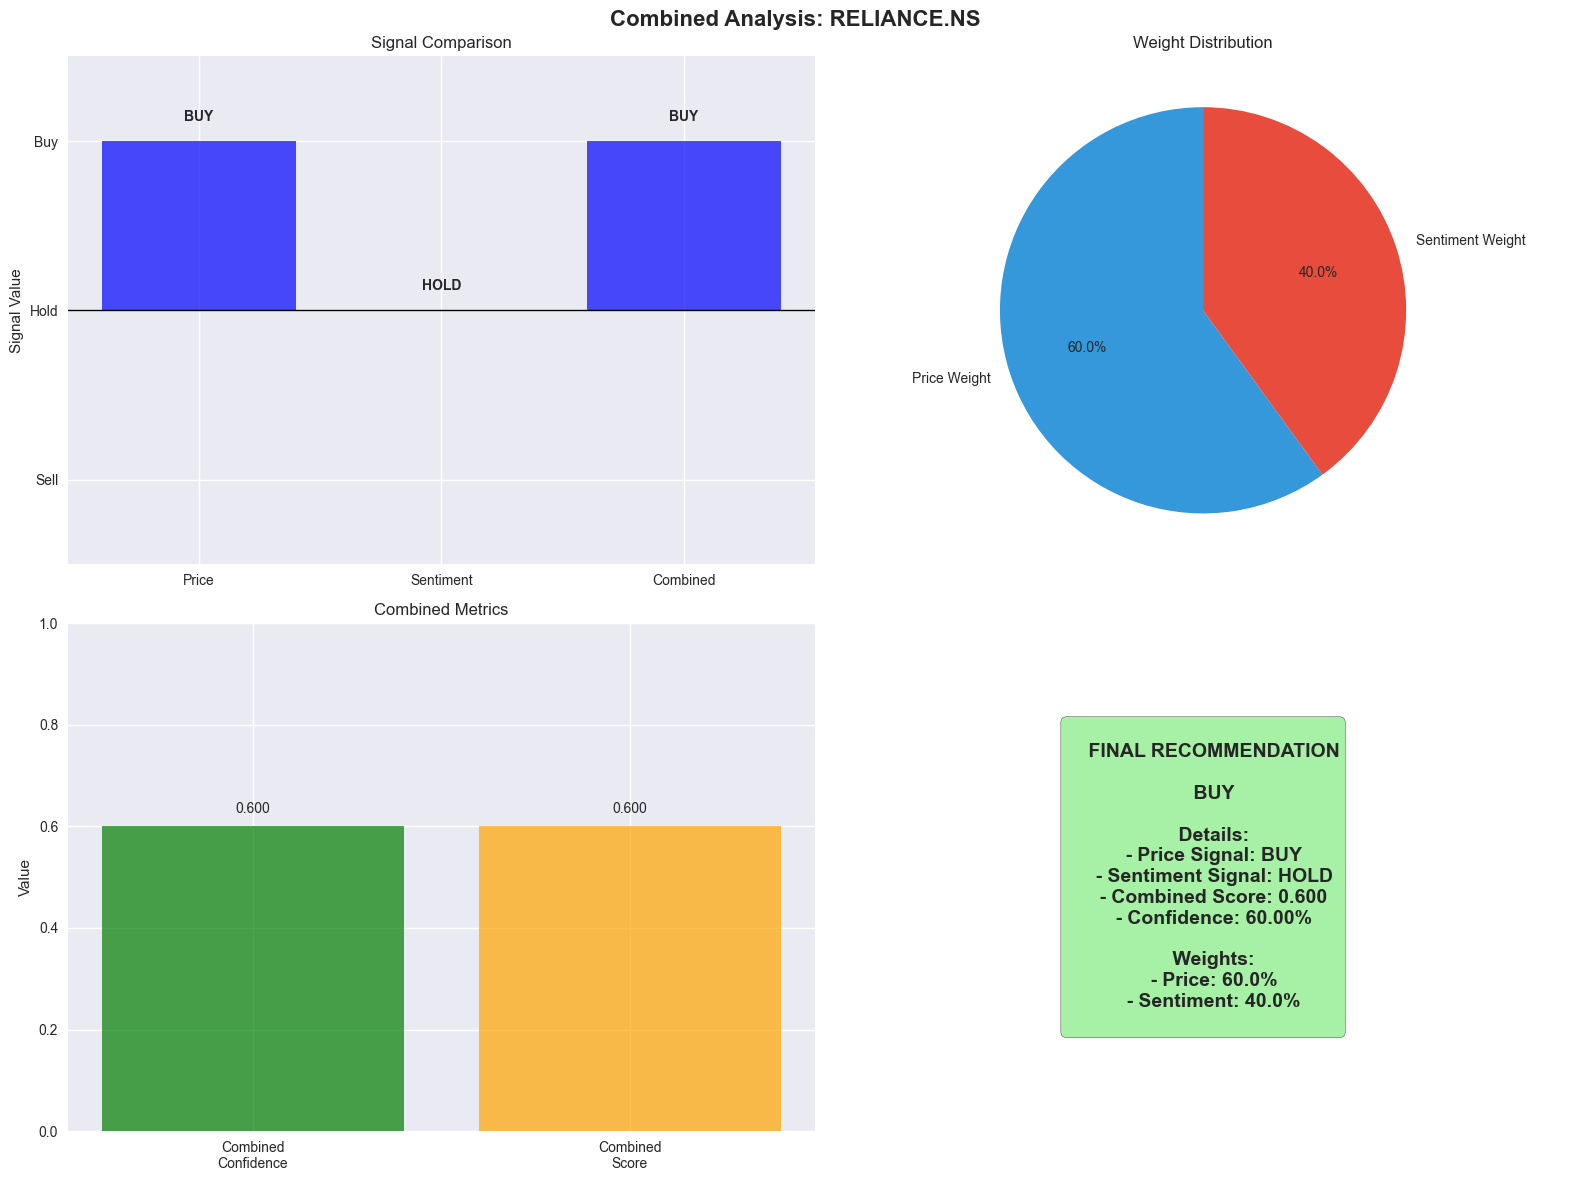


📊 Creating visualizations for TCS.NS...


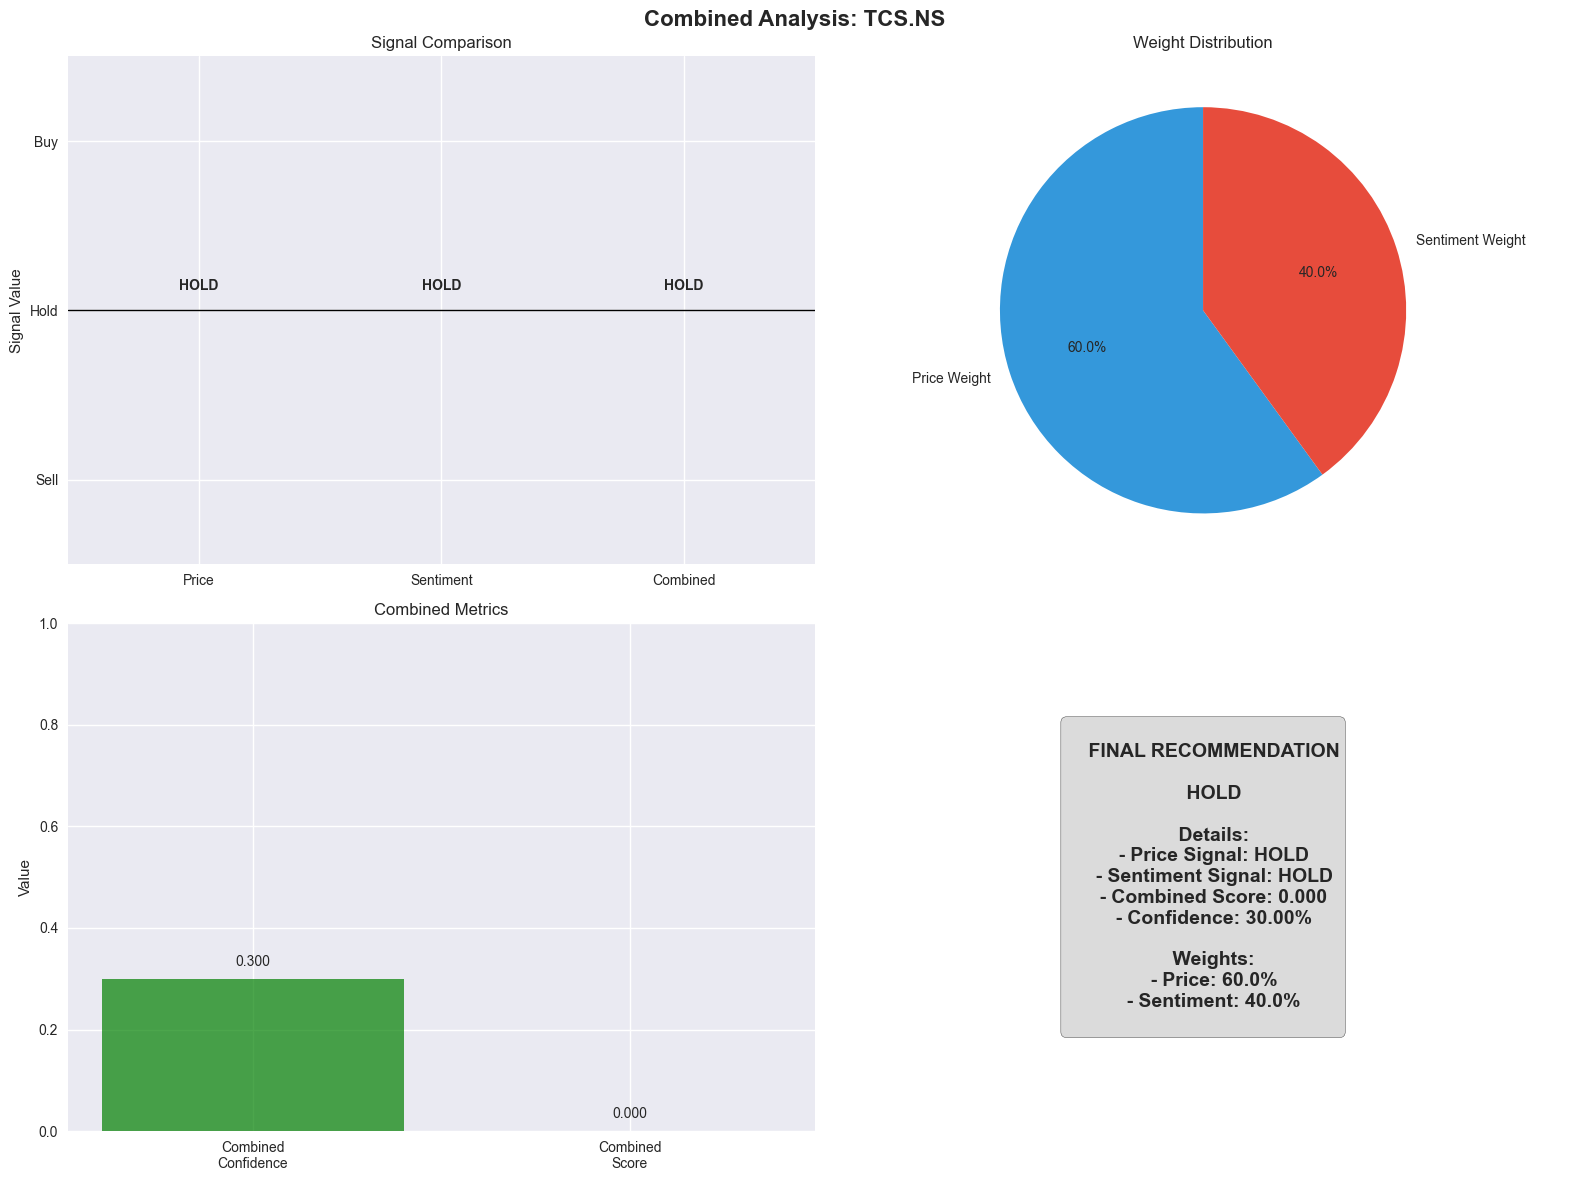


📊 COMBINED PREDICTION SUMMARY REPORT

📈 Overall Distribution:
   BUY:   1 stocks
   SELL:  0 stocks
   HOLD:  1 stocks

📋 Detailed Recommendations:
Ticker          Recommendation  Price Signal Sentiment Signal Confidence  
--------------------------------------------------------------------------------
RELIANCE.NS     BUY             BUY          HOLD            60.0%
TCS.NS          HOLD            HOLD         HOLD            30.0%

💾 Report saved to results/combined_predictions/summary_report.txt

✅ All visualizations and reports generated!


In [ ]:
# Cell 20: Visualization & Results Analysis

def plot_sentiment_analysis(ticker: str, sentiment_data: Dict, save_path: str = None):
    """Plot sentiment analysis results"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Sentiment Analysis: {ticker}', fontsize=16, fontweight='bold')
    
    # Sentiment distribution
    ax1 = axes[0, 0]
    dist = sentiment_data.get('sentiment_distribution', {})
    if dist:
        labels = list(dist.keys())
        counts = list(dist.values())
        colors = ['red' if l == 'negative' else 'green' if l == 'positive' else 'gray' for l in labels]
        ax1.bar(labels, counts, color=colors, alpha=0.7)
        ax1.set_title('Sentiment Distribution')
        ax1.set_ylabel('Article Count')
    
    # Sentiment score over time (if available)
    ax2 = axes[0, 1]
    scores = sentiment_data.get('raw_scores', [])
    if scores:
        ax2.plot(range(len(scores)), scores, marker='o', alpha=0.6)
        ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
        ax2.axhline(y=SENTIMENT_CONFIG['sentiment_threshold'], color='green', linestyle='--', alpha=0.5, label='Buy Threshold')
        ax2.axhline(y=-SENTIMENT_CONFIG['sentiment_threshold'], color='red', linestyle='--', alpha=0.5, label='Sell Threshold')
        ax2.set_title('Sentiment Scores')
        ax2.set_xlabel('Article Index')
        ax2.set_ylabel('Sentiment Score')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # Confidence metrics
    ax3 = axes[1, 0]
    confidence = sentiment_data.get('confidence', 0.0)
    sentiment = sentiment_data.get('sentiment', 'neutral')
    score = sentiment_data.get('score', 0.0)
    
    metrics = ['Confidence', 'Score']
    values = [confidence, abs(score)]
    colors_metric = ['blue', 'orange']
    bars = ax3.bar(metrics, values, color=colors_metric, alpha=0.7)
    ax3.set_ylim(0, 1)
    ax3.set_title('Sentiment Metrics')
    ax3.set_ylabel('Value')
    for bar, val in zip(bars, values):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom')
    
    # Summary text
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = f"""
    Sentiment Analysis Summary
    
    Overall Sentiment: {sentiment.upper()}
    Confidence: {confidence:.2%}
    Score: {score:.3f}
    Articles Analyzed: {sentiment_data.get('article_count', 0)}
    
    Distribution:
    - Positive: {dist.get('positive', 0)}
    - Negative: {dist.get('negative', 0)}
    - Neutral: {dist.get('neutral', 0)}
    """
    ax4.text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_combined_analysis(ticker: str, combined_prediction: Dict, price_signals_data: Dict = None):
    """Plot combined price and sentiment analysis"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Combined Analysis: {ticker}', fontsize=16, fontweight='bold')
    
    # Signal comparison
    ax1 = axes[0, 0]
    signals = ['Price', 'Sentiment', 'Combined']
    signal_map = {'buy': 1, 'hold': 0, 'sell': -1}
    
    price_sig_val = signal_map.get(combined_prediction['price_signal'].lower(), 0)
    sent_sig_val = signal_map.get(combined_prediction['sentiment_signal'].lower(), 0)
    final_sig_val = signal_map.get(combined_prediction['final_recommendation'].lower(), 0)
    
    values = [price_sig_val, sent_sig_val, final_sig_val]
    colors = ['blue' if v > 0 else 'red' if v < 0 else 'gray' for v in values]
    
    bars = ax1.bar(signals, values, color=colors, alpha=0.7)
    ax1.set_ylim(-1.5, 1.5)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax1.set_title('Signal Comparison')
    ax1.set_ylabel('Signal Value')
    ax1.set_yticks([-1, 0, 1])
    ax1.set_yticklabels(['Sell', 'Hold', 'Buy'])
    
    for bar, sig in zip(bars, [combined_prediction['price_signal'], 
                              combined_prediction['sentiment_signal'],
                              combined_prediction['final_recommendation']]):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1 if bar.get_height() >= 0 else bar.get_height() - 0.1,
                sig.upper(), ha='center', va='bottom' if bar.get_height() >= 0 else 'top', fontweight='bold')
    
    # Weight contribution
    ax2 = axes[0, 1]
    weights = combined_prediction['weights']
    labels = ['Price Weight', 'Sentiment Weight']
    sizes = [weights['price'], weights['sentiment']]
    colors_pie = ['#3498db', '#e74c3c']
    ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
    ax2.set_title('Weight Distribution')
    
    # Confidence metrics
    ax3 = axes[1, 0]
    confidence = combined_prediction['confidence']
    combined_score = combined_prediction['combined_score']
    
    metrics = ['Combined\nConfidence', 'Combined\nScore']
    values_metric = [confidence, abs(combined_score)]
    bars = ax3.bar(metrics, values_metric, color=['green', 'orange'], alpha=0.7)
    ax3.set_ylim(0, 1)
    ax3.set_title('Combined Metrics')
    ax3.set_ylabel('Value')
    for bar, val in zip(bars, values_metric):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom')
    
    # Final recommendation summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    final_signal = combined_prediction['final_recommendation'].upper()
    summary_text = f"""
    FINAL RECOMMENDATION
    
    {final_signal}
    
    Details:
    - Price Signal: {combined_prediction['price_signal'].upper()}
    - Sentiment Signal: {combined_prediction['sentiment_signal'].upper()}
    - Combined Score: {combined_score:.3f}
    - Confidence: {confidence:.2%}
    
    Weights:
    - Price: {weights['price']:.1%}
    - Sentiment: {weights['sentiment']:.1%}
    """
    
    # Color based on recommendation
    bg_color = 'lightgreen' if final_signal == 'BUY' else 'lightcoral' if final_signal == 'SELL' else 'lightgray'
    
    ax4.text(0.5, 0.5, summary_text, fontsize=14, fontweight='bold',
             horizontalalignment='center', verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor=bg_color, alpha=0.8))
    
    plt.tight_layout()
    safe_ticker = re.sub(r'[^A-Za-z0-9_-]+', '_', ticker)
    save_path = f"{CONFIG['results_dir']}/combined_predictions/{safe_ticker}_combined_analysis.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def create_combined_summary_report(all_predictions: Dict):
    """Create comprehensive summary report"""
    print("\n" + "="*80)
    print("📊 COMBINED PREDICTION SUMMARY REPORT")
    print("="*80)
    
    buy_count = sum(1 for p in all_predictions.values() if p.get('final_recommendation', '').lower() == 'buy')
    sell_count = sum(1 for p in all_predictions.values() if p.get('final_recommendation', '').lower() == 'sell')
    hold_count = sum(1 for p in all_predictions.values() if p.get('final_recommendation', '').lower() == 'hold')
    
    print(f"\n📈 Overall Distribution:")
    print(f"   BUY:  {buy_count:2d} stocks")
    print(f"   SELL: {sell_count:2d} stocks")
    print(f"   HOLD: {hold_count:2d} stocks")
    
    print(f"\n📋 Detailed Recommendations:")
    print(f"{'Ticker':<15} {'Recommendation':<15} {'Price Signal':<12} {'Sentiment Signal':<15} {'Confidence':<12}")
    print("-"*80)
    
    for ticker, pred in sorted(all_predictions.items()):
        if 'error' not in pred:
            print(f"{ticker:<15} {pred['final_recommendation'].upper():<15} "
                  f"{pred['price_signal'].upper():<12} {pred['sentiment_signal'].upper():<15} "
                  f"{pred['confidence']:.1%}")
        else:
            print(f"{ticker:<15} ERROR: {pred['error']}")
    
    # Save report
    report_path = f"{CONFIG['results_dir']}/combined_predictions/summary_report.txt"
    with open(report_path, 'w') as f:
        f.write("COMBINED PREDICTION SUMMARY REPORT\n")
        f.write("="*80 + "\n\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        f.write(f"Overall Distribution:\n")
        f.write(f"  BUY:  {buy_count} stocks\n")
        f.write(f"  SELL: {sell_count} stocks\n")
        f.write(f"  HOLD: {hold_count} stocks\n\n")
        f.write("Detailed Recommendations:\n")
        f.write("-"*80 + "\n")
        for ticker, pred in sorted(all_predictions.items()):
            if 'error' not in pred:
                f.write(f"{ticker}: {pred['final_recommendation'].upper()} "
                       f"(Price: {pred['price_signal'].upper()}, "
                       f"Sentiment: {pred['sentiment_signal'].upper()}, "
                       f"Confidence: {pred['confidence']:.1%})\n")
    
    print(f"\n💾 Report saved to {report_path}")


# Generate visualizations and reports
if 'all_combined_predictions' in locals() and len(all_combined_predictions) > 0:
    print("\n🎨 Generating visualizations...")
    
    # Plot for each stock
    for ticker, prediction in all_combined_predictions.items():
        if 'error' not in prediction:
            print(f"\n📊 Creating visualizations for {ticker}...")
            
            # Plot combined analysis
            plot_combined_analysis(ticker, prediction, price_signals if 'price_signals' in locals() else None)
            
            # Plot sentiment analysis if available
            sentiment_details = prediction.get('sentiment_details', {})
            if sentiment_details and sentiment_details.get('article_count', 0) > 0:
                plot_sentiment_analysis(ticker, sentiment_details)
    
    # Create summary report
    create_combined_summary_report(all_combined_predictions)
    
    print("\n✅ All visualizations and reports generated!")
else:
    print("⚠️ No combined predictions available. Run prediction generation first.")
